# UNIDAD 7: Inferencia Estadística y Prueba de Hipótesis

**Duración:** 2.5 semanas (15 horas)

**Curso:** Probabilidad y Estadística Inferencial

**Institución:** Universidad de la Ciénega del Estado de Michoacán de Ocampo (UCEMICH)

**Profesor:** Luis José Yudico Anaya

**Carrera:** Ingeniería en Nanotecnología

**Nivel:** Tercer Semestre

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiagent-AI-Lab/Probability-Statistics-Agentic-AI-Core/blob/master/notebooks/UNIDAD_7_INFERENCIA_ESTIMACION.ipynb)

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    repo_dir = "Probability-Statistics-Agentic-AI-Core"
    if not os.path.exists(repo_dir):
        !git clone -q https://github.com/Multiagent-AI-Lab/{repo_dir}.git
    os.chdir(repo_dir)
    %pip install -q -r requirements.txt
else:
    # Entorno local: ubicar la raiz del repo subiendo desde el cwd
    # (donde se lanzo Jupyter) y ponerla en sys.path para que
    # `from src.multiagent_core...` resuelva sin importar la carpeta actual.
    _raiz = next(
        (p for p in (Path.cwd(), *Path.cwd().parents)
         if (p / "src" / "multiagent_core").is_dir()),
        Path.cwd(),
    )
    if str(_raiz) not in sys.path:
        sys.path.insert(0, str(_raiz))


## Prerequisitos de esta unidad

- **Distribuciones Muestrales: Chi-cuadrada, t-Student y F** (Unidad 5) — señaladas explícitamente en la Parte C de esa unidad como "prerequisito de Inferencia"; son la base de todas las pruebas paramétricas de esta unidad.
- **Estadística Descriptiva y Medidas de Tendencia Central** (Unidad 1) — insumo directo para los estimadores puntuales (Método de Momentos, MLE) desarrollados aquí.
- **Ciclo de Verificación Triple** (ver `GOVERNANCE.md`) — como en todas las unidades del curso, cada concepto con forma cerrada se verifica primero simbólicamente (SymPy) y luego se reproduce con las herramientas de producción (SciPy/statsmodels) antes de interpretarse.

## 1. Fundamentación Teórica de la Inferencia Estadística

La **Prueba de Hipótesis Estadística** es el proceso formal de utilizar información muestral para confirmar o refutar una aseveración (hipótesis) sobre un parámetro desconocido $\theta$ asociado a una distribución de probabilidad $f(x; \theta)$ de una población. Es una de las dos ramas centrales de la inferencia estadística (junto con la estimación de parámetros) y es la herramienta cuantitativa estándar para validar afirmaciones sobre procesos experimentales en ingeniería.

### 1.1 Hipótesis Nula y Alternativa
Una hipótesis estadística paramétrica es la verificación de una aseveración sobre el parámetro desconocido $\theta$:

* **Hipótesis Nula ($H_0$)**: la aseveración por defecto sobre el parámetro, denotada $H_0: \theta \in \Theta_0$. Por convención, el signo de igualdad ($=$, $\ge$ o $\le$) siempre se incluye en $H_0$.
* **Hipótesis Alternativa ($H_1$)**: la afirmación complementaria, $H_1: \theta \in \Theta_1 = \Theta \setminus \Theta_0$, que se sostiene solo si la evidencia muestral es suficientemente fuerte en su contra.

### 1.2 Estadístico de Prueba y Región Crítica
* **Estadístico de Prueba**: una estadística cuyo valor se calcula a partir de la muestra observada y cuya distribución bajo $H_0$ se conoce.
* **Región Crítica (o de Rechazo)**: el conjunto de valores del estadístico de prueba para los cuales $H_0$ se rechaza en favor de $H_1$.

### 1.3 Errores Tipo I y Tipo II
Al decidir entre $H_0$ y $H_1$ con información parcial (una muestra), se pueden cometer dos tipos de errores:

| | $H_0$ es verdadera | $H_0$ es falsa |
|:---:|:---:|:---:|
| **No rechazar $H_0$** | Decisión correcta | Error Tipo II ($\beta$) |
| **Rechazar $H_0$** | Error Tipo I ($\alpha$) | Decisión correcta |

* **Error Tipo I**: rechazar $H_0$ cuando en realidad es verdadera. Su probabilidad es el **nivel de significancia** $\alpha = P(\text{rechazar } H_0 \mid H_0 \text{ verdadera})$.
* **Error Tipo II**: no rechazar $H_0$ cuando en realidad es falsa, con probabilidad $\beta = P(\text{no rechazar } H_0 \mid H_0 \text{ falsa})$.
* **Poder de la Prueba**: $1-\beta$, la probabilidad de rechazar correctamente $H_0$ cuando es falsa.

**Ejemplo (cálculo de $\alpha$ y $\beta$)**: sea $X \sim \text{Exp}(\lambda)$, con $H_0: \mu = 20$ contra $H_1: \mu = 30$ ($\mu = 1/\lambda$), y regla de decisión "rechazar $H_0$ si $x > 28$" con una única observación:
$$\alpha = P(X > 28 \mid \mu=20) = e^{-28/20} \approx \boxed{0.2466}$$
$$\beta = P(X \le 28 \mid \mu=30) = 1 - e^{-28/30} \approx \boxed{0.6068}$$

**Verificación computacional (contexto AgNPs)**: usando el mismo control de calidad de la Sección 2 ($H_0:\mu=50$ nm, $\sigma=4$ nm, $n=36$, $\alpha=0.05$ bilateral), se calculan $\alpha$, $\beta$ y la potencia $1-\beta$ para una alternativa concreta $\mu_1=48$ nm (una desviación real del proceso que se quiere poder detectar):

In [2]:
from scipy.stats import norm

## Reutiliza el contexto de la Seccion 2: AgNPs, sigma=4, n=36, alpha=0.05
mu_0, sigma, n = 50, 4, 36
alpha = 0.05
error_estandar = sigma / n ** 0.5

## Region critica bilateral: rechazar H0 si |z0| > z_{alpha/2}
z_critico = norm.ppf(1 - alpha / 2)
limite_inferior = mu_0 - z_critico * error_estandar
limite_superior = mu_0 + z_critico * error_estandar

## Hipotesis alternativa concreta: el proceso realmente se desvio a mu_1 = 48 nm
mu_1 = 48

## Error Tipo II: P(no rechazar H0 | H1 verdadera) = P(limite_inf < X_bar < limite_sup | mu=mu_1)
beta = norm.cdf(limite_superior, loc=mu_1, scale=error_estandar) - norm.cdf(limite_inferior, loc=mu_1, scale=error_estandar)
potencia = 1 - beta

print(f"Region de no rechazo: ({limite_inferior:.4f}, {limite_superior:.4f}) nm")
print(f"alpha={alpha}, beta={beta:.4f}, potencia={potencia:.4f}")


Region de no rechazo: (48.6934, 51.3066) nm
alpha=0.05, beta=0.1492, potencia=0.8508


```
Region de no rechazo: (48.6934, 51.3066) nm
alpha=0.05, beta=0.1492, potencia=0.8508

```

Con $\alpha=0.05$ fijo, el test detecta correctamente una desviación real a $\mu_1=48$ nm el $85.08\%$ de las veces ($\beta=0.1492$): si el proceso se desvía tan poco como 2 nm, todavía existe un $14.92\%$ de probabilidad de no detectarlo con este tamaño de muestra.

### 1.4 El Valor p (p-value)
El **p-valor** es la probabilidad de obtener un resultado igual o más extremo que el observado, asumiendo que $H_0$ es verdadera. Es la métrica más usada en la práctica porque resume toda la evidencia contra $H_0$ en un solo número, sin necesidad de tabular valores críticos: se rechaza $H_0$ si $\text{p-valor} < \alpha$.

### 1.5 Lema de Neyman–Pearson y Pruebas Más Potentes (UMP)
Para un nivel $\alpha$ fijo, la teoría de Neyman–Pearson busca minimizar $\beta$ (maximizar el poder). Un test que logra esto para toda alternativa se llama **uniformemente más potente (UMP)**.

**Teorema (Lema de Neyman–Pearson)**: para $H_0: \theta=\theta_0$ contra $H_1: \theta=\theta_1$, el test más potente de tamaño $\alpha$ rechaza $H_0$ cuando el cociente de verosimilitud (likelihood ratio) excede una constante $k$:
$$\varphi(x) = \begin{cases} 1 & \text{si } f_1(x)/f_0(x) > k \\ 0 & \text{si } f_1(x)/f_0(x) < k \end{cases}$$

**Ejemplo**: con $f_0(x) = 2x$ y $f_1(x) = 2(1-x)$ en $(0,1)$, el cociente $f_1/f_0 = (1-x)/x$ lleva a rechazar $H_0$ si $X < 1/(1+k)$. Resolviendo $\alpha = \int_0^{1/(1+k)} 2t\,dt$ se obtiene $k = (1-\sqrt{\alpha})/\sqrt{\alpha}$, de modo que la región de rechazo óptima es $X < \sqrt{\alpha}$, con función de potencia $1-(1-\sqrt{\alpha})^2$.

**Verificación computacional (razón de verosimilitud sobre la media de una Normal)**: usando de nuevo $H_0:\mu=50$ nm contra $H_1:\mu=48$ nm ($\sigma=4$ nm, $n=36$, $\alpha=0.05$, contexto AgNPs de la Sección 2), el cociente de verosimilitud entre dos Normales con la misma varianza es monótono en $\bar x$, así que la región de rechazo óptima de Neyman–Pearson es unilateral (cola izquierda, hacia $\mu_1<\mu_0$). Se construye esa región y se confirma numéricamente que ninguna otra región de tamaño $\le\alpha$ logra mayor potencia:

In [3]:
import numpy as np
from scipy.stats import norm

## H0: mu = mu_0 = 50 nm  vs  H1: mu = mu_1 = 48 nm (mismo contexto AgNPs, sigma=4, n=36)
mu_0, mu_1, sigma, n = 50, 48, 4, 36
alpha = 0.05
error_estandar = sigma / n ** 0.5

## Neyman-Pearson: para mu_1 < mu_0, el cociente de verosimilitud f1/f0 > k
## equivale a rechazar H0 para valores PEQUEnos de x_bar (cola izquierda),
## consistente con el sentido de la desviacion bajo H1.
z_critico = norm.ppf(1 - alpha)  # cola unilateral izquierda
umbral_rechazo = mu_0 - z_critico * error_estandar

## Potencia del test NP (region de rechazo: x_bar < umbral_rechazo)
potencia_np = norm.cdf(umbral_rechazo, loc=mu_1, scale=error_estandar)

## Confirmacion numerica de optimalidad: cualquier otra region del mismo
## tamano alpha (desplazada) tiene potencia menor o igual bajo H1.
desplazamientos = np.linspace(-2, 2, 401)
potencias_alternativas = []
for d in desplazamientos:
    umbral_alt = umbral_rechazo + d
    alpha_alt = norm.cdf(umbral_alt, loc=mu_0, scale=error_estandar)
    if alpha_alt <= alpha:
        pot_alt = norm.cdf(umbral_alt, loc=mu_1, scale=error_estandar)
        potencias_alternativas.append(pot_alt)

print(f"Umbral de rechazo (NP): x_bar < {umbral_rechazo:.4f} nm")
print(f"Potencia del test NP: {potencia_np:.4f}")
print(f"Maxima potencia entre regiones alternativas de tamano <= alpha: {max(potencias_alternativas):.4f}")
print(f"El test NP es optimo: {potencia_np >= max(potencias_alternativas) - 1e-9}")


Umbral de rechazo (NP): x_bar < 48.9034 nm
Potencia del test NP: 0.9123
Maxima potencia entre regiones alternativas de tamano <= alpha: 0.9123
El test NP es optimo: True


```
Umbral de rechazo (NP): x_bar < 48.9034 nm
Potencia del test NP: 0.9123
Maxima potencia entre regiones alternativas de tamano <= alpha: 0.9123
El test NP es optimo: True

```

Ninguna región de rechazo alternativa con el mismo tamaño $\alpha=0.05$ supera la potencia de $0.9123$ obtenida por la región de Neyman–Pearson — confirmando numéricamente que la región basada en el cociente de verosimilitud es, en efecto, la más potente.

### 1.6 Prueba para la Media Poblacional (Z-test y t-test)
Sea $X_1,\dots,X_n$ una muestra de $N(\mu, \sigma^2)$, con hipótesis $H_0:\mu=\mu_0$ contra $H_1:\mu\neq\mu_0$.

**Varianza $\sigma^2$ conocida (Z-test)**:
$$Z = \frac{\bar{X} - \mu_0}{\sigma/\sqrt{n}} \sim N(0,1)$$
Se rechaza $H_0$ si $z_0 \notin (-z_{\alpha/2},\ z_{\alpha/2})$.

**Varianza $\sigma^2$ desconocida (t-test)**: se reemplaza $\sigma$ por la desviación muestral $s$, y el estadístico sigue una distribución $t$ de Student con $n-1$ grados de libertad:
$$t = \frac{\bar{X}-\mu_0}{s/\sqrt{n}} \sim t_{n-1}$$
Se rechaza $H_0$ si $t_0 < -t_{\alpha/2,n-1}$ o $t_0 > t_{\alpha/2,n-1}$ (para $n\ge30$, $t_{n-1}$ se aproxima bien por $N(0,1)$).

**Ejemplo resuelto (Z-test)**: notas de examen $\sim N(\mu, 0.25)$ ($\sigma=0.5$ conocida), $n=50$, $\bar{x}=7.8$, $\alpha=0.01$. $H_0:\mu=8$ contra $H_1:\mu\neq8$:
$$z_0 = \frac{7.8-8}{0.5/\sqrt{50}} \approx \boxed{-2.83}$$
Con $\alpha=0.01$ bilateral, $z_{0.005}=2.57$. Como $-2.83 < -2.57$, se **rechaza $H_0$**.

### 1.7 Prueba para la Varianza
Para $H_0:\sigma^2=\sigma_0^2$ contra $H_1:\sigma^2\neq\sigma_0^2$, el estadístico de prueba sigue una distribución Chi-cuadrado con $n-1$ grados de libertad:
$$\chi^2_0 = \frac{(n-1)s^2}{\sigma_0^2} \sim \chi^2_{n-1}$$
Se rechaza $H_0$ si $\chi^2_0 > \chi^2_{n-1,\alpha/2}$ o $\chi^2_0 < \chi^2_{n-1,1-\alpha/2}$.

**Ejemplo resuelto**: $\sigma_0 = 0.4\%$ histórico, muestra de $n=24$ semanas con $s=0.38\%$, $\alpha=0.05$. $H_0:\sigma^2=0.16$ contra $H_1:\sigma^2\neq0.16$: se calcula $\chi^2_0 \approx 20.76$, con región crítica $\chi^2_0 < 11.689$ o $\chi^2_0 > 38.076$ (para $df=23$). Como $20.76$ cae dentro del intervalo, **no se rechaza $H_0$**.

**Verificación computacional**: se reproduce el cálculo anterior con `scipy.stats.chi2`, confirmando el mismo estadístico y la misma decisión ya publicados en prosa.

In [4]:
from scipy.stats import chi2

## Contexto ya establecido en la Seccion 1.7: control de calidad del proceso,
## sigma_0 = 0.4% (historico), muestra n=24 semanas con s=0.38%, alpha=0.05
sigma_0, n, s, alpha = 0.4, 24, 0.38, 0.05
df = n - 1

chi2_0 = (df * s ** 2) / sigma_0 ** 2

chi2_critico_superior = chi2.ppf(1 - alpha / 2, df)
chi2_critico_inferior = chi2.ppf(alpha / 2, df)

print(f"chi2_0 = {chi2_0:.4f}")
print(f"Region critica: chi2_0 < {chi2_critico_inferior:.3f} o chi2_0 > {chi2_critico_superior:.3f}")
print(f"Se rechaza H0: {chi2_0 < chi2_critico_inferior or chi2_0 > chi2_critico_superior}")


chi2_0 = 20.7575
Region critica: chi2_0 < 11.689 o chi2_0 > 38.076
Se rechaza H0: False


```
chi2_0 = 20.7575
Region critica: chi2_0 < 11.689 o chi2_0 > 38.076
Se rechaza H0: False

```

El valor $\chi^2_0=20.7575$ coincide con el $\approx20.76$ calculado a mano y confirma que cae dentro de la región de no rechazo.

### 1.8 Pruebas Chi-cuadrado de Bondad de Ajuste, Contingencia y Proporciones
Además de la media y la varianza, la familia $\chi^2$ cubre tres pruebas no paramétricas de uso constante en control de calidad:

* **Bondad de Ajuste**: evalúa si una muestra proviene de una distribución específica, comparando frecuencias observadas $O_i$ contra esperadas $E_i = nP_i$ en $k$ categorías: $D^2 = \sum_{i=1}^k (O_i-E_i)^2/E_i \sim \chi^2_{k-1}$ (o $\chi^2_{k-1-r}$ si se estimaron $r$ parámetros de la muestra).
* **Tablas de Contingencia (Independencia)**: evalúa si dos variables categóricas son independientes, con frecuencia esperada $e_{ij} = (r_i \cdot c_j)/N$ por celda y estadístico $D^2 = \sum_{i,j} (n_{ij}-e_{ij})^2/e_{ij} \sim \chi^2_{(r-1)(c-1)}$.
* **Igualdad de Proporciones (Homogeneidad)**: evalúa $H_0: p_1=p_2=\dots=p_k$ contra $H_1$: al menos una proporción difiere, estimando una proporción común $\hat{p}$ y aplicando el mismo esquema $\chi^2$ sobre las celdas de éxito/fracaso.

En los tres casos se rechaza $H_0$ cuando el estadístico supera el valor crítico $\chi^2$ correspondiente, o equivalentemente cuando el p-valor es menor que $\alpha$.

**Ejemplo — Bondad de Ajuste**: se registran los tiempos entre fallas de $n=150$ nano-sensores piezoresistivos, agrupados en $k=4$ intervalos, y se desea verificar si siguen una distribución Exponencial con $\lambda=0.005$ ($\alpha=0.01$). Con frecuencias observadas/esperadas por intervalo, el estadístico de prueba resulta $D_0^2 \approx 12.79$, con $k-1=3$ grados de libertad. El valor crítico es $\chi^2_{3,\,0.01} \approx 11.34$. Como $D_0^2 = 12.79 > 11.34$, **se rechaza $H_0$**: los tiempos entre fallas no son consistentes con una distribución Exponencial($\lambda=0.005$).

**Ejemplo — Tabla de Contingencia**: se desea evaluar si el **método de síntesis** de nanopartículas de oro (Turkevich vs. método alternativo) es independiente de la **presencia de agregación** observada por TEM. Con una tabla $2\times 2$ de frecuencias observadas y $\alpha=0.05$, el estadístico $D_0^2$ se compara contra $\chi^2_{1,\,0.05}$; el procedimiento sigue el mismo esquema de bondad de ajuste, sustituyendo las frecuencias esperadas por celda $e_{ij}=(r_i \cdot c_j)/N$.

**Verificación computacional**: se evalúa un caso concreto de tabla de contingencia $3\times 3$ — **tipo de defecto** (agregación, subrecubrimiento, ninguno) observado por TEM vs. **lote de producción** (A, B, C) de AgNPs — usando `scipy.stats.chi2_contingency`, que calcula el estadístico, los grados de libertad, el p-valor y las frecuencias esperadas en un solo paso:

In [5]:
import numpy as np
from scipy.stats import chi2_contingency

## Tabla de contingencia: tipo de defecto (agregacion, subrecubrimiento, ninguno)
## vs. lote de produccion (Lote A, Lote B, Lote C) de AgNPs
## Filas: tipo de defecto; Columnas: lote
tabla = np.array([
    [12,  8, 15],   # Agregacion
    [ 7, 18,  9],   # Subrecubrimiento
    [41, 34, 36],   # Ninguno
])

alpha = 0.05
chi2_stat, p_valor, df, esperadas = chi2_contingency(tabla)

print(f"Estadistico chi2 = {chi2_stat:.4f}")
print(f"Grados de libertad = {df}")
print(f"p-valor = {p_valor:.4f}")
print("Frecuencias esperadas:")
print(np.round(esperadas, 2))
print(f"Se rechaza H0 (independencia): {p_valor < alpha}")


Estadistico chi2 = 8.8758
Grados de libertad = 4
p-valor = 0.0643
Frecuencias esperadas:
[[11.67 11.67 11.67]
 [11.33 11.33 11.33]
 [37.   37.   37.  ]]
Se rechaza H0 (independencia): False


```
Estadistico chi2 = 8.8758
Grados de libertad = 4
p-valor = 0.0643
Frecuencias esperadas:
[[11.67 11.67 11.67]
 [11.33 11.33 11.33]
 [37.   37.   37.  ]]
Se rechaza H0 (independencia): False

```

Con $p=0.0643 > \alpha=0.05$, **no se rechaza $H_0$**: la evidencia muestral no es suficiente para concluir que el tipo de defecto depende del lote de producción, aunque el p-valor está cerca del umbral y ameritaría vigilancia en lotes futuros.

**Ejemplo — Igualdad de Proporciones**: se comparan las proporciones de nanopartículas defectuosas en $k=4$ lotes de síntesis de AgNPs ($H_0: p_1=p_2=p_3=p_4$ contra $H_1$: al menos una proporción difiere). Se estima la proporción común $\hat p$ a partir de los datos agregados, se calculan las frecuencias esperadas de "defectuoso"/"no defectuoso" por lote, y se aplica el estadístico $\chi^2$ con $k-1=3$ grados de libertad para decidir si el proceso de síntesis es consistente entre lotes.

**Verificación computacional**: se compara la **tasa de rendimiento de síntesis** (proporción de partículas exitosas) entre el método Turkevich y un método alternativo de reducción química, usando la misma `scipy.stats.chi2_contingency` sobre una tabla $2\times 2$ de éxito/fracaso (equivalente a la prueba de igualdad de dos proporciones):

In [6]:
import numpy as np
from scipy.stats import chi2_contingency

## Comparacion de tasa de rendimiento (sintesis exitosa) entre dos metodos
## de sintesis de AgNPs: Turkevich vs. metodo alternativo (reduccion quimica)
## Filas: exito/fracaso; Columnas: metodo
exitos = np.array([171, 148])       # Turkevich, Alternativo
n_total = np.array([200, 180])
fracasos = n_total - exitos

tabla = np.array([exitos, fracasos])

alpha = 0.05
chi2_stat, p_valor, df, esperadas = chi2_contingency(tabla)

p1, p2 = exitos / n_total
print(f"Proporcion de exito Turkevich: {p1:.4f}")
print(f"Proporcion de exito Alternativo: {p2:.4f}")
print(f"Estadistico chi2 = {chi2_stat:.4f}")
print(f"Grados de libertad = {df}")
print(f"p-valor = {p_valor:.4f}")
print(f"Se rechaza H0 (p1 = p2): {p_valor < alpha}")


Proporcion de exito Turkevich: 0.8550
Proporcion de exito Alternativo: 0.8222
Estadistico chi2 = 0.5317
Grados de libertad = 1
p-valor = 0.4659
Se rechaza H0 (p1 = p2): False


```
Proporcion de exito Turkevich: 0.8550
Proporcion de exito Alternativo: 0.8222
Estadistico chi2 = 0.5317
Grados de libertad = 1
p-valor = 0.4659
Se rechaza H0 (p1 = p2): False

```

Con $p=0.4659 \gg \alpha=0.05$, **no se rechaza $H_0$**: no hay evidencia estadística de que la tasa de rendimiento difiera entre los dos métodos de síntesis.

### 1.9 Método de los Momentos (Estimación Puntual)

El **Método de los Momentos (MoM)** es, junto con la Máxima Verosimilitud (MLE, ver §6.2-6.3), una técnica clásica de estimación puntual. Su idea es simple: igualar los **momentos poblacionales** (esperanza, varianza, etc.) con los **momentos muestrales** correspondientes, y despejar los parámetros desconocidos.

**Procedimiento general**: si una distribución tiene $k$ parámetros $\theta_1,\dots,\theta_k$, se plantean $k$ ecuaciones igualando los primeros $k$ momentos poblacionales $\mu_j = E[X^j]$ con los momentos muestrales $m_j = \frac{1}{n}\sum_{i=1}^n x_i^j$, y se resuelve el sistema para los $\theta$.

**Caso 1 — Distribución Exponencial (un parámetro)**: para $X \sim \text{Exp}(\lambda)$, el primer momento poblacional es $E[X] = 1/\lambda$. Igualando con la media muestral $\bar{x}$:
$$\bar{x} = \frac{1}{\hat{\lambda}_{MoM}} \quad\Longrightarrow\quad \hat{\lambda}_{MoM} = \frac{1}{\bar{x}}$$

**Caso 2 — Distribución Gamma (dos parámetros)**: para $X \sim \text{Gamma}(\alpha,\beta)$ (parametrización forma-escala), $E[X]=\alpha\beta$ y $\text{Var}(X)=\alpha\beta^2$. Igualando con $m_1=\bar{x}$ y $m_2=s^2$ (varianza muestral) y resolviendo el sistema:
$$\hat{\alpha}_{MoM} = \frac{m_1^2}{m_2} \qquad \hat{\beta}_{MoM} = \frac{m_2}{m_1}$$

**Contexto de nanotecnología**: se mide el tiempo hasta degradación oxidativa (en horas) de una muestra de $n=50$ nanopartículas de oro (AuNPs) sin recubrimiento protector, modelado como $\text{Exp}(\lambda)$; y por separado, el tamaño de $n=60$ nanoclusters de paladio sintetizados por reducción química, modelado como $\text{Gamma}(\alpha,\beta)$ (una distribución más flexible que la Normal para tamaños que no pueden ser negativos).

**Verificación simbólica**:

In [7]:
import sympy as sp

## Metodo de Momentos para la Exponencial: E[X] = 1/lambda
lam, m1 = sp.symbols('lambda m1', positive=True)
sol_expon = sp.solve(sp.Eq(m1, 1/lam), lam)
print(f"Exponencial MoM: lambda_hat = {sol_expon[0]}")  # 1/m1

## Metodo de Momentos para la Gamma: E[X]=alpha*beta, Var[X]=alpha*beta^2
alpha, beta, mu1, mu2 = sp.symbols('alpha beta mu1 mu2', positive=True)
sistema = [sp.Eq(mu1, alpha*beta), sp.Eq(mu2, alpha*beta**2)]
sol_gamma = sp.solve(sistema, [alpha, beta])
print(f"Gamma MoM: alpha_hat = {sol_gamma[0][0]}, beta_hat = {sol_gamma[0][1]}")


Exponencial MoM: lambda_hat = 1/m1
Gamma MoM: alpha_hat = mu1**2/mu2, beta_hat = mu2/mu1


**Solución computacional**:

In [8]:
import numpy as np
import scipy.stats as stats

## --- Caso 1: Exponencial, tiempo de degradacion oxidativa de AuNPs (horas) ---
np.random.seed(101)
tiempo_degradacion = stats.expon.rvs(scale=18.0, size=50)  # lambda verdadero = 1/18

media_muestral = np.mean(tiempo_degradacion)
lambda_mom = 1 / media_muestral
print(f"Media muestral: {media_muestral:.4f} h")
print(f"lambda_MoM = {lambda_mom:.4f}  (verdadero lambda = 1/18 = {1/18:.4f})")

## --- Caso 2: Gamma, tamano de nanoclusters de Pd (nm) ---
np.random.seed(102)
diametros_pd = stats.gamma.rvs(a=4.0, scale=2.5, size=60)  # alpha=4.0, beta=2.5 verdaderos

m1 = np.mean(diametros_pd)
m2_var = np.var(diametros_pd, ddof=0)
alpha_mom = m1**2 / m2_var
beta_mom = m2_var / m1
print(f"\nGamma MoM: alpha_hat = {alpha_mom:.4f} (verdadero 4.0), beta_hat = {beta_mom:.4f} (verdadero 2.5)")

## Comparacion contra MLE (scipy.stats.gamma.fit, loc fijo en 0)
alpha_mle, _, beta_mle = stats.gamma.fit(diametros_pd, floc=0)
print(f"Gamma MLE: alpha_hat = {alpha_mle:.4f}, beta_hat = {beta_mle:.4f}")


Media muestral: 18.7903 h
lambda_MoM = 0.0532  (verdadero lambda = 1/18 = 0.0556)

Gamma MoM: alpha_hat = 4.3877 (verdadero 4.0), beta_hat = 2.0966 (verdadero 2.5)
Gamma MLE: alpha_hat = 3.9220, beta_hat = 2.3455


**Interpretación**: con $n=50$, $\hat{\lambda}_{MoM} = 0.0532\ \text{h}^{-1}$ (verdadero $1/18=0.0556$), un error relativo pequeño esperado por variabilidad muestral. Para la Gamma, el MoM ($\hat\alpha=4.39$, $\hat\beta=2.10$) y el MLE ($\hat\alpha=3.92$, $\hat\beta=2.35$) difieren ligeramente entre sí — ambos son estimadores consistentes (convergen al valor verdadero cuando $n\to\infty$), pero el MoM es computacionalmente más simple (no requiere optimización numérica) mientras que el MLE es generalmente más eficiente (menor varianza asintótica). En la práctica, el MoM se usa frecuentemente como valor inicial para algoritmos iterativos de MLE.

$$\boxed{\hat{\lambda}_{MoM} = \frac{1}{\bar{x}} = 0.0532\ \text{h}^{-1} \qquad \hat{\alpha}_{MoM} = 4.39,\ \ \hat{\beta}_{MoM} = 2.10}$$

### 1.10 Pruebas No Paramétricas: Kolmogorov-Smirnov, Mann-Whitney-Wilcoxon y Kruskal-Wallis

Las pruebas vistas hasta §1.8 (Z, t, $\chi^2$) son **paramétricas**: asumen una forma funcional conocida (típicamente Normal) para la distribución subyacente. Cuando esta suposición no se cumple —distribuciones asimétricas, muestras pequeñas, o presencia de outliers—, las pruebas **no paramétricas** (basadas en rangos u órdenes, no en los valores originales) ofrecen alternativas más robustas.

**Mapa de decisión de la familia de pruebas**. El diagrama es un panorama general para ubicar cada prueba. Esta unidad desarrolla en detalle P1 (§1.6), la familia χ² de conteos (§1.8) y las no paramétricas N1, N2, N4 y N5 (§1.10-1.11); P2, P3 y N3 se incluyen como mapa de referencia y se desarrollan en cursos posteriores. La primera bifurcación distingue el **tipo de dato**: las pruebas χ² de bondad de ajuste, contingencia y proporciones operan sobre conteos/categorías y no requieren normalidad ni homocedasticidad. Para datos de medición continua, la prueba de Levene (§1.12) decide la bifurcación de homocedasticidad; si falla, Welch es la alternativa paramétrica robusta antes de pasar a rangos.

```mermaid
graph TD
    Inicio["Contrastar una hipotesis sobre datos"]
    Inicio --> Q0{"Tipo de dato: medicion continua o conteos/categorias?"}
    Q0 -->|"Conteos / categorias"| Chi["Familia chi-cuadrada (1.8): bondad de ajuste, contingencia, proporciones -- sin supuesto de normalidad"]
    Q0 -->|"Medicion continua"| Q1{"Normalidad en cada grupo? (Shapiro-Wilk)"}
    Q1 -->|"No"| NoParam["Rama no parametrica (basada en rangos)"]
    Q1 -->|"Si"| Q2{"Homocedasticidad? (Levene, seccion 1.12)"}
    Q2 -->|"No"| Welch["Welch (t o ANOVA) como alternativa robusta; si tampoco basta, rama no parametrica"]
    Q2 -->|"Si"| Param["Rama parametrica clasica"]
    Welch --> NoParam
    Param --> P1["1 media vs valor: Z-test o t de una muestra (1.6)"]
    Param --> P2["2 medias independientes: t de dos muestras (mapa de referencia)"]
    Param --> P3["3+ medias: ANOVA de una via (mapa de referencia)"]
    NoParam --> N1["2 grupos independientes: Mann-Whitney U (1.10)"]
    NoParam --> N2["3+ grupos independientes: Kruskal-Wallis H (1.10)"]
    NoParam --> N3["Datos apareados: Wilcoxon de rangos con signo (mapa de referencia)"]
    NoParam --> N4["Solo orden o mediana vs valor: prueba de signos (1.11)"]
    NoParam --> N5["Misma distribucion entre 2 muestras: KS de dos muestras (1.10)"]

```

![Diagrama](../docs/images/UNIDAD_7_INFERENCIA_ESTIMACION_1.svg)


**Kolmogorov-Smirnov (KS) de dos muestras**: a diferencia del KS de una muestra ya usado en §6.3 (bondad de ajuste contra una distribución teórica), el KS de dos muestras evalúa si dos conjuntos de datos independientes provienen de la **misma distribución**, sin asumir ninguna forma específica. El estadístico compara las funciones de distribución empíricas (CDF) de ambas muestras:
$$D_{n,m} = \sup_x |F_n(x) - F_m(x)|$$
donde $F_n$ y $F_m$ son las CDF empíricas de cada muestra. Valores grandes de $D$ indican que las distribuciones difieren.

**Mann-Whitney-Wilcoxon U**: compara dos muestras independientes sin asumir normalidad, usando la suma de rangos combinados en vez de las medias — por eso es robusta ante outliers que distorsionarían un t-test:
$$U_1 = n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1$$
donde $R_1$ es la suma de rangos del grupo 1 tras combinar y ordenar ambas muestras.

**Kruskal-Wallis H**: generaliza Mann-Whitney a $k>2$ grupos independientes (es el análogo no paramétrico de ANOVA de una vía), usando también rangos combinados:
$$H = \frac{12}{N(N+1)}\sum_{i=1}^k \frac{R_i^2}{n_i} - 3(N+1)$$
Bajo $H_0$ (todas las poblaciones tienen la misma distribución), $H \sim \chi^2_{k-1}$ aproximadamente.

**Contexto de nanotecnología (KS)**: se comparan los diámetros de AgNPs sintetizadas por dos métodos distintos (reducción con citrato vs. con borohidruro de sodio) para verificar si producen la misma distribución de tamaños.

**Contexto de nanotecnología (Mann-Whitney)**: se mide la dureza Vickers (HV) de nanocompuestos cerámica-nanotubos de carbono con dos concentraciones de refuerzo; el grupo A tiene una lectura anómala (aglomerado local de CNT) que distorsiona su media.

**Contexto de nanotecnología (Kruskal-Wallis)**: se comparan ángulos de contacto de recubrimientos hidrofóbicos con tres tipos de nanopartículas (SiO$_2$, TiO$_2$, ZnO), donde ZnO presenta mayor varianza por inestabilidad del proceso de síntesis — la condición de homogeneidad de varianzas requerida por ANOVA (ver §1.12, Levene) se viola, justificando el uso de Kruskal-Wallis.

**Solución computacional**:

In [9]:
import numpy as np
import scipy.stats as stats

## --- KS de dos muestras: diametro de AgNPs, dos metodos de sintesis ---
np.random.seed(201)
metodo_citrato = stats.norm.rvs(loc=50, scale=4, size=40)
metodo_borohidruro = stats.lognorm.rvs(s=0.25, scale=48, size=40)

ks_stat, ks_p = stats.ks_2samp(metodo_citrato, metodo_borohidruro)
print(f"KS 2-muestras (Citrato vs Borohidruro): D={ks_stat:.4f}, p-valor={ks_p:.4f}")
print("Conclusion:", "Distribuciones distintas (rechaza H0)" if ks_p < 0.05 else "No hay evidencia de diferencia")

## --- Mann-Whitney U: dureza Vickers, nanocompuestos con outlier ---
dureza_A = np.array([410, 430, 390, 400, 420, 980])   # 980 HV = aglomerado anomalo de CNT
dureza_B = np.array([550, 600, 580, 620, 590, 570])

t_stat, t_p = stats.ttest_ind(dureza_A, dureza_B, equal_var=False)
print(f"\nWelch t-test (enganado por outlier): t={t_stat:.4f}, p-valor={t_p:.4f}")

u_stat, u_p = stats.mannwhitneyu(dureza_A, dureza_B, alternative='less')
print(f"Mann-Whitney U (H1: A < B, una cola): U={u_stat:.4f}, p-valor={u_p:.4f}")

## --- Kruskal-Wallis: angulo de contacto, 3 recubrimientos con varianzas distintas ---
np.random.seed(202)
rec_SiO2 = np.random.normal(105, 5, 15)
rec_TiO2 = np.random.normal(118, 5, 15)
rec_ZnO = np.random.normal(112, 14, 15)   # mayor varianza (sintesis inestable)

h_stat, h_p = stats.kruskal(rec_SiO2, rec_TiO2, rec_ZnO)
print(f"\nKruskal-Wallis H: H={h_stat:.4f}, p-valor={h_p:.6f}")
print("Conclusion:", "Al menos un recubrimiento difiere (rechaza H0)" if h_p < 0.05 else "No se detecta diferencia")


KS 2-muestras (Citrato vs Borohidruro): D=0.4250, p-valor=0.0013
Conclusion: Distribuciones distintas (rechaza H0)

Welch t-test (enganado por outlier): t=-0.8360, p-valor=0.4405
Mann-Whitney U (H1: A < B, una cola): U=6.0000, p-valor=0.0325

Kruskal-Wallis H: H=16.4854, p-valor=0.000263
Conclusion: Al menos un recubrimiento difiere (rechaza H0)


**Interpretación**: el KS de dos muestras rechaza $H_0$ ($D=0.4250$, $p=0.0013$): los dos métodos de síntesis de AgNPs producen distribuciones de tamaño distinguibles, pese a tener medias similares (el KS es sensible a diferencias en la *forma* completa de la distribución, no solo en la media). En el caso de dureza, el t-test bilateral **no detecta diferencia** ($p=0.4405$) porque el outlier de 980 HV infla artificialmente la varianza y la media del grupo A; el Mann-Whitney dirigido ($H_1: A<B$), al basarse en rangos, sí detecta que B es consistentemente más duro ($p=0.0325 < 0.05$) — el mismo patrón de robustez que ilustra por qué estas pruebas son preferibles ante outliers. Finalmente, Kruskal-Wallis rechaza $H_0$ con fuerte evidencia ($p=0.000263$): al menos un recubrimiento produce un ángulo de contacto distinto — este resultado es el prerrequisito para el post-hoc de Dunn de §1.14.

$$\boxed{D_{KS}=0.4250\ (p=0.0013) \qquad U_{MW}=6.0\ (p=0.0325,\ \text{una cola}) \qquad H_{KW}=16.4854\ (p=0.000263)}$$

### 1.11 Prueba de Signos y Prueba de la Mediana

Cuando ni siquiera se puede asumir que los datos son simétricos o que la escala de medición es de intervalo (solo orden), las pruebas basadas en **signos** son las más robustas de toda la familia no paramétrica: ignoran la magnitud de las diferencias y usan solamente su dirección.

**Prueba de Signos**: contrasta si la mediana de una población es igual a un valor de referencia $\theta_0$: $H_0: \tilde\mu = \theta_0$ contra $H_1: \tilde\mu \neq \theta_0$. Se cuenta cuántas observaciones caen por encima ($n_+$) y por debajo ($n_-$) de $\theta_0$ (los empates exactos se descartan), y bajo $H_0$ cada observación tiene probabilidad $0.5$ de caer en cualquiera de los dos lados — por lo tanto $n_+ \sim \text{Binomial}(n_+ + n_-,\ 0.5)$ bajo $H_0$. Esto convierte la prueba de signos en un caso directo de prueba binomial exacta.

**Prueba de la Mediana**: generaliza la idea anterior a $k$ grupos independientes. Se calcula la mediana combinada de todas las observaciones (agrupando los $k$ grupos), se clasifica cada observación de cada grupo como "por encima" o "por debajo" de esa mediana combinada, y se construye una tabla de contingencia $2\times k$ que se evalúa con un test $\chi^2$ de independencia (ver §1.8) — la hipótesis nula es que los $k$ grupos comparten la misma mediana poblacional.

**Contexto de nanotecnología (Signos)**: se mide la rugosidad superficial (nm, vía AFM) de $n=20$ obleas recubiertas con un nuevo proceso de deposición, y se contrasta si la mediana del proceso iguala la especificación histórica de $\theta_0=2.5\ \text{nm}$.

**Contexto de nanotecnología (Mediana)**: se comparan tres lotes independientes de síntesis de AgNPs (diámetro en nm) para verificar si comparten la misma mediana de tamaño, sin asumir normalidad.

**Solución computacional**:

In [10]:
import numpy as np
import scipy.stats as stats

## --- Prueba de Signos: rugosidad superficial vs especificacion (2.5 nm) ---
np.random.seed(301)
rugosidad = np.round(stats.norm.rvs(loc=2.8, scale=0.6, size=20), 2)
theta_0 = 2.5

n_mayor = np.sum(rugosidad > theta_0)
n_menor = np.sum(rugosidad < theta_0)
n_efectivo = n_mayor + n_menor  # excluye empates exactos con theta_0, si los hubiera

resultado_signos = stats.binomtest(n_mayor, n_efectivo, 0.5, alternative='two-sided')
print(f"Rugosidad: n_mayor={n_mayor}, n_menor={n_menor} (n_efectivo={n_efectivo})")
print(f"Prueba de Signos: p-valor = {resultado_signos.pvalue:.4f}")
print("Conclusion:", "Rechaza H0: mediana != 2.5 nm" if resultado_signos.pvalue < 0.05 else "No rechaza H0")

## --- Prueba de la Mediana: 3 lotes de sintesis de AgNPs ---
np.random.seed(302)
lote_1 = stats.norm.rvs(loc=50, scale=3, size=12)
lote_2 = stats.norm.rvs(loc=53, scale=3, size=12)
lote_3 = stats.norm.rvs(loc=49, scale=3, size=12)

stat_mediana, p_mediana, mediana_combinada, tabla = stats.median_test(lote_1, lote_2, lote_3)
print(f"\nMediana combinada: {mediana_combinada:.4f} nm")
print(f"Estadistico chi2: {stat_mediana:.4f}, p-valor: {p_mediana:.4f}")
print("Tabla de contingencia (fila 0 = por encima, fila 1 = por debajo):")
print(tabla)


Rugosidad: n_mayor=15, n_menor=5 (n_efectivo=20)
Prueba de Signos: p-valor = 0.0414
Conclusion: Rechaza H0: mediana != 2.5 nm

Mediana combinada: 49.3434 nm
Estadistico chi2: 2.6667, p-valor: 0.2636
Tabla de contingencia (fila 0 = por encima, fila 1 = por debajo):
[[6 8 4]
 [6 4 8]]


**Interpretación**: la prueba de signos rechaza $H_0$ ($p=0.0414 < 0.05$): 15 de 20 obleas tienen rugosidad por encima de 2.5 nm, evidencia de que la mediana real del nuevo proceso se desvió de la especificación histórica — sin necesitar ningún supuesto sobre la forma de la distribución de rugosidades. La prueba de la mediana, en cambio, **no rechaza** $H_0$ ($p=0.2636$): con estas muestras no hay evidencia suficiente de que los tres lotes difieran en su mediana de diámetro, aunque sus medias muestrales numéricas difieran ligeramente (50, 53, 49 nm) — la prueba de la mediana es intencionalmente conservadora porque descarta toda la información salvo la posición relativa a la mediana global.

$$\boxed{\text{Signos: } p=0.0414\ (\text{rechaza}) \qquad \text{Mediana: } \chi^2=2.6667,\ p=0.2636\ (\text{no rechaza})}$$

### 1.12 Prueba de Levene (Homogeneidad de Varianzas)

La prueba de Levene contrasta $H_0: \sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$ contra $H_1$: al menos una varianza difiere. Es el **prerrequisito estándar** antes de aplicar ANOVA clásico (que asume varianzas homogéneas entre grupos) — si Levene rechaza $H_0$, se debe usar una alternativa robusta (Welch's ANOVA o el Kruskal-Wallis de §1.10).

A diferencia de la prueba $\chi^2$ para una sola varianza (§1.7), que exige normalidad estricta, Levene es robusta ante desviaciones de la normalidad porque no trabaja directamente con los datos $x_{ij}$, sino con sus **desviaciones absolutas respecto a la mediana de cada grupo** $z_{ij} = |x_{ij} - \tilde{x}_i|$, y luego aplica un ANOVA de una vía sobre esos $z_{ij}$:
$$W = \frac{(N-k)}{(k-1)} \cdot \frac{\sum_{i=1}^k n_i (\bar{z}_i - \bar{z})^2}{\sum_{i=1}^k \sum_{j=1}^{n_i} (z_{ij}-\bar{z}_i)^2} \sim F_{k-1,\ N-k} \ \text{(aprox., bajo } H_0\text{)}$$

**Contexto de nanotecnología**: se reutilizan los mismos tres grupos de ángulo de contacto de §1.10 (SiO$_2$, TiO$_2$, ZnO) — el gap de Levene es precisamente el que justifica formalmente por qué esos datos requirieron Kruskal-Wallis en vez de ANOVA.

**Solución computacional**:

In [11]:
import numpy as np
import scipy.stats as stats

np.random.seed(202)
rec_SiO2 = np.random.normal(105, 5, 15)
rec_TiO2 = np.random.normal(118, 5, 15)
rec_ZnO = np.random.normal(112, 14, 15)

lev_stat, lev_p = stats.levene(rec_SiO2, rec_TiO2, rec_ZnO)
print(f"Levene: W = {lev_stat:.4f}, p-valor = {lev_p:.6f}")

if lev_p < 0.05:
    print("Conclusion: Rechaza H0. Varianzas NO homogeneas -> usar Kruskal-Wallis, no ANOVA clasico.")
else:
    print("Conclusion: No rechaza H0. Varianzas homogeneas -> ANOVA clasico es valido.")


Levene: W = 9.0366, p-valor = 0.000544
Conclusion: Rechaza H0. Varianzas NO homogeneas -> usar Kruskal-Wallis, no ANOVA clasico.


**Interpretación**: Levene rechaza $H_0$ ($W=9.0366$, $p=0.000544$), confirmando numéricamente que ZnO (con $\sigma=14$ frente a $\sigma=5$ de los otros dos recubrimientos) rompe el supuesto de homocedasticidad — exactamente la razón por la que en §1.10 se usó Kruskal-Wallis en lugar de ANOVA para comparar los tres recubrimientos.

$$\boxed{W_{\text{Levene}} = 9.0366,\quad p = 0.000544\ (\text{varianzas heterogéneas})}$$

### 1.13 Tamaño del Efecto: $d$ de Cohen

El p-valor indica *si* existe evidencia de una diferencia, pero no dice nada sobre *cuán grande* es esa diferencia en términos prácticos — con una muestra suficientemente grande, hasta una diferencia trivial resulta estadísticamente significativa (ver el misconception ya documentado al final de esta unidad). El **tamaño del efecto** cuantifica la magnitud de la diferencia entre dos grupos en unidades de desviación estándar, independientemente del tamaño de muestra.

Para dos grupos independientes con medias $\bar{x}_1,\bar{x}_2$ y desviaciones estándar muestrales $s_1,s_2$ (tamaños $n_1,n_2$), la $d$ de Cohen usa la **desviación estándar combinada (pooled)**:
$$s_{pooled} = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}} \qquad d = \frac{\bar{x}_1-\bar{x}_2}{s_{pooled}}$$

**Regla práctica de interpretación** (Cohen, 1988): $|d|\approx 0.2$ efecto pequeño, $|d|\approx 0.5$ mediano, $|d|\approx 0.8$ grande.

**Contexto de nanotecnología**: se compara la conductividad eléctrica ($\text{S/m}$, escala arbitraria de medición) de nanocables de óxido de zinc antes y después de un proceso de dopaje con aluminio, para cuantificar no solo si el dopaje tiene efecto, sino qué tan grande es ese efecto.

**Solución computacional**:

In [12]:
import numpy as np
import scipy.stats as stats

np.random.seed(501)
sin_dopaje = stats.norm.rvs(loc=120, scale=18, size=25)
con_dopaje = stats.norm.rvs(loc=145, scale=20, size=25)

n1, n2 = len(sin_dopaje), len(con_dopaje)
s1, s2 = np.std(sin_dopaje, ddof=1), np.std(con_dopaje, ddof=1)
s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
cohens_d = (np.mean(con_dopaje) - np.mean(sin_dopaje)) / s_pooled

t_stat, p_val = stats.ttest_ind(con_dopaje, sin_dopaje, equal_var=True)

print(f"Media sin dopaje: {np.mean(sin_dopaje):.4f} S/m")
print(f"Media con dopaje:  {np.mean(con_dopaje):.4f} S/m")
print(f"s_pooled: {s_pooled:.4f}")
print(f"\nt-test: t={t_stat:.4f}, p-valor={p_val:.6f}")
print(f"Cohen's d = {cohens_d:.4f}")


Media sin dopaje: 125.3666 S/m
Media con dopaje:  142.1873 S/m
s_pooled: 22.3221

t-test: t=2.6642, p-valor=0.010477
Cohen's d = 0.7535


**Interpretación**: el t-test confirma significancia estadística ($p=0.0105<0.05$), pero es la $d$ de Cohen la que cuantifica la magnitud práctica: $d=0.75$ es un efecto **grande** según la regla de Cohen — el dopaje con aluminio no solo produce una diferencia detectable, sino una mejora sustancial de la conductividad respecto a la variabilidad natural del proceso, relevante para decisiones de ingeniería más allá de la mera significancia estadística.

$$\boxed{d_{\text{Cohen}} = \frac{142.19-125.37}{22.32} \approx 0.75\ (\text{efecto grande})}$$

### 1.14 Comparaciones Múltiples Post-Hoc: Dunn con Corrección de Bonferroni

Cuando Kruskal-Wallis (§1.10) rechaza $H_0$, sabemos que *al menos uno* de los $k$ grupos difiere, pero no *cuáles*. Responder esa pregunta exige comparar todos los pares posibles ($\binom{k}{2}$ comparaciones), pero hacerlo con Mann-Whitney repetido sin ajuste infla el Error Tipo I global: con $\alpha=0.05$ y varias comparaciones, la probabilidad de al menos un falso positivo crece muy por encima de $0.05$ — el mismo problema de pruebas múltiples que motiva la corrección de Bonferroni en otros contextos del curso.

**Prueba de Dunn**: es el post-hoc no paramétrico diseñado específicamente para seguir a Kruskal-Wallis. Reutiliza los mismos rangos combinados del test de Kruskal-Wallis y compara cada par de rangos promedio mediante un estadístico $z$:
$$z_{ij} = \frac{\bar{R}_i - \bar{R}_j}{\sqrt{\left(\frac{N(N+1)}{12} - \frac{C}{12(N-1)}\right)\left(\frac{1}{n_i}+\frac{1}{n_j}\right)}}$$
donde $\bar{R}_i$ es el rango promedio del grupo $i$, $N$ el tamaño total, y $C=\sum(t^3-t)$ una corrección por empates (rangos repetidos). El p-valor de cada comparación se obtiene de la Normal estándar, y luego se ajusta con la **corrección de Bonferroni** (ya introducida en §1.8 con la familia $\chi^2$, y aplicable aquí de forma idéntica):
$$p_{\text{ajustado}} = \min\left(1,\ p_{\text{raw}} \times \binom{k}{2}\right)$$

**Contexto de nanotecnología**: se retoman los tres recubrimientos hidrofóbicos de §1.10-1.12 (SiO$_2$, TiO$_2$, ZnO), donde Kruskal-Wallis ya rechazó $H_0$ — el post-hoc de Dunn identifica cuál(es) par(es) específico(s) de recubrimientos difieren realmente.

**Solución computacional** (implementación directa de la fórmula de Dunn, ya que no todo entorno tiene instalado el paquete opcional `scikit-posthocs`):

In [13]:
import numpy as np
import scipy.stats as stats

def dunn_bonferroni(*grupos, etiquetas=None):
    """Prueba de Dunn post-hoc (Dunn, 1964) con correccion de Bonferroni,
    a partir de los rangos combinados usados por Kruskal-Wallis."""
    k = len(grupos)
    datos_combinados = np.concatenate(grupos)
    N = len(datos_combinados)
    rangos = stats.rankdata(datos_combinados)

    tamanos = [len(g) for g in grupos]
    limites = np.cumsum([0] + tamanos)
    rangos_por_grupo = [rangos[limites[i]:limites[i+1]] for i in range(k)]
    rango_promedio = [np.mean(r) for r in rangos_por_grupo]

    ## Correccion por empates (ties)
    _, conteos = np.unique(datos_combinados, return_counts=True)
    correccion_empates = np.sum(conteos**3 - conteos) / (12 * (N - 1))

    n_comparaciones = k * (k - 1) // 2
    resultados = []
    for i in range(k):
        for j in range(i + 1, k):
            se = np.sqrt((N*(N+1)/12 - correccion_empates) * (1/tamanos[i] + 1/tamanos[j]))
            z = (rango_promedio[i] - rango_promedio[j]) / se
            p_raw = 2 * (1 - stats.norm.cdf(abs(z)))
            p_bonferroni = min(1.0, p_raw * n_comparaciones)
            nombre_i = etiquetas[i] if etiquetas else f"G{i}"
            nombre_j = etiquetas[j] if etiquetas else f"G{j}"
            resultados.append((f"{nombre_i} vs {nombre_j}", z, p_raw, p_bonferroni))
    return resultados

np.random.seed(202)
rec_SiO2 = np.random.normal(105, 5, 15)
rec_TiO2 = np.random.normal(118, 5, 15)
rec_ZnO = np.random.normal(112, 14, 15)

print(f"{'Comparacion':<15}{'z':>10}{'p_raw':>12}{'p_bonferroni':>15}")
for comparacion, z, p_raw, p_bonf in dunn_bonferroni(rec_SiO2, rec_TiO2, rec_ZnO, etiquetas=["SiO2","TiO2","ZnO"]):
    marca = " *" if p_bonf < 0.05 else ""
    print(f"{comparacion:<15}{z:>10.4f}{p_raw:>12.6f}{p_bonf:>15.6f}{marca}")


Comparacion             z       p_raw   p_bonferroni
SiO2 vs TiO2      -4.0591    0.000049       0.000148 *
SiO2 vs ZnO       -2.1129    0.034605       0.103816
TiO2 vs ZnO        1.9461    0.051639       0.154916


**Interpretación**: tras la corrección de Bonferroni, solo la comparación **SiO$_2$ vs TiO$_2$** sigue siendo significativa ($p_{\text{bonf}}=0.000148$); las comparaciones que involucran ZnO (SiO$_2$ vs ZnO: $p_{\text{bonf}}=0.1038$; TiO$_2$ vs ZnO: $p_{\text{bonf}}=0.1549$) dejan de serlo tras el ajuste, pese a que sin corrección alguna hubiera parecido significativa la comparación SiO$_2$ vs ZnO ($p_{\text{raw}}=0.0346 < 0.05$). Esto ilustra directamente por qué la corrección es necesaria: la alta varianza de ZnO (ya detectada por Levene en §1.12) hace que sus rangos se solapen más con los de los otros grupos, reduciendo la potencia estadística para distinguirlo con confianza tras controlar el error acumulado.

$$\boxed{\text{Único par significativo tras Bonferroni: SiO}_2\text{ vs TiO}_2\ (p_{\text{bonf}}=0.000148)}$$

### 1.15 Regresión Logística: Wald, LRT, GLM Binomial y Odds Ratio

Cuando la variable respuesta es **binaria** (éxito/fracaso, colapso/supervivencia) en vez de continua, la regresión lineal (que asume $Y$ continua y normal) no es apropiada — sus predicciones no están acotadas en $[0,1]$. La **regresión logística** modela en su lugar la probabilidad de éxito $\pi(x)$ mediante la función logística (sigmoide), transformando el problema a un **Modelo Lineal Generalizado (GLM)** con función de enlace *logit* y componente aleatorio Binomial:
$$\ln\left(\frac{\pi(x)}{1-\pi(x)}\right) = \beta_0 + \beta_1 x \qquad\Longleftrightarrow\qquad \pi(x) = \frac{1}{1+e^{-(\beta_0+\beta_1 x)}}$$

**Interpretación de $\beta_1$ — Odds Ratio (razón de momios)**: si $x$ aumenta en una unidad, el *log-odds* de éxito aumenta en $\beta_1$; equivalentemente, la razón de momios $\text{ODDS}=\pi/(1-\pi)$ se multiplica por $e^{\beta_1}$ (el **odds ratio**).

**Los tres tests para $H_0:\beta_1=0$** (introducidos conceptualmente en el marco general de la unidad, aquí aplicados en la práctica):
* **Wald**: $z = \hat\beta_1 / SE(\hat\beta_1)$, comparado contra $N(0,1)$ — el más simple, reportado automáticamente por `statsmodels`.
* **Razón de Verosimilitud (LRT)**: compara la log-verosimilitud del modelo completo contra el modelo nulo (solo intercepto): $\Lambda = -2[\ell(H_0) - \ell(H_1)] \sim \chi^2_1$ bajo $H_0$ — más preciso que Wald en muestras pequeñas o cerca de separación completa.

**Contexto de nanotecnología**: se expone un cultivo celular a distintas dosis de nanopartículas de plata (AgNP, mg/L) y se registra si el cultivo colapsa (mortalidad $>50\%$) o sobrevive — un ejemplo clásico de curva dosis-respuesta en nanotoxicología, donde interesa además estimar la **LD$_{50}$** (dosis letal media, la dosis a la cual $\pi(x)=0.5$).

**Solución computacional**:

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   24
Model:                          Logit   Df Residuals:                       22
Method:                           MLE   Df Model:                            1
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:                  0.6371
Time:                        13:22:49   Log-Likelihood:                -5.9163
converged:                       True   LL-Null:                       -16.301
Covariance Type:            nonrobust   LLR p-value:                 5.182e-06
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.6189      2.913     -2.272      0.023     -12.329      -0.909
x1             0.4415      0.187      2.356      0.018       0.074       0.809

Wald: z=2.3565, p-valor=0.018448
LRT:  stat=20.7687

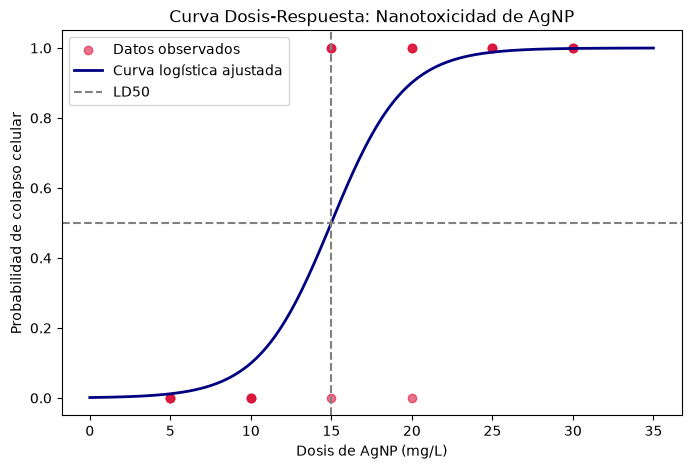

In [14]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Dosis de AgNP (mg/L) replicada 4 veces por nivel, y resultado binario de colapso celular
dosis = np.array([5,5,5,5, 10,10,10,10, 15,15,15,15, 20,20,20,20, 25,25,25,25, 30,30,30,30], dtype=float)

np.random.seed(701)
logits_verdaderos = -6 + 0.35 * dosis
probs_verdaderas = 1 / (1 + np.exp(-logits_verdaderos))
np.random.seed(702)
colapso = np.random.binomial(1, probs_verdaderas)

X = sm.add_constant(dosis)
modelo_completo = sm.Logit(colapso, X).fit(disp=0)
modelo_nulo = sm.Logit(colapso, np.ones(len(colapso))).fit(disp=0)
print(modelo_completo.summary())

## Wald test (directo del summary)
wald_z, wald_p = modelo_completo.tvalues[1], modelo_completo.pvalues[1]

## Likelihood-Ratio Test (LRT)
lrt_stat = -2 * (modelo_nulo.llf - modelo_completo.llf)
lrt_p = stats.chi2.sf(lrt_stat, df=1)

## Odds ratio y LD50
odds_ratio = np.exp(modelo_completo.params[1])
beta0, beta1 = modelo_completo.params
ld50 = -beta0 / beta1

print(f"\nWald: z={wald_z:.4f}, p-valor={wald_p:.6f}")
print(f"LRT:  stat={lrt_stat:.4f}, p-valor={lrt_p:.6f}")
print(f"Odds ratio por mg/L adicional: {odds_ratio:.4f}")
print(f"LD50 (dosis letal 50%): {ld50:.4f} mg/L")

## GLM Binomial equivalente (misma estimacion, distinta interfaz)
modelo_glm = sm.GLM(colapso, X, family=sm.families.Binomial()).fit()
print(f"\nGLM Binomial: beta1={modelo_glm.params[1]:.6f} (coincide con Logit: {modelo_completo.params[1]:.6f})")

## Curva sigmoide de dosis-respuesta
x_plot = np.linspace(0, 35, 200)
y_pred = modelo_completo.predict(sm.add_constant(x_plot))
plt.figure(figsize=(8, 5))
plt.scatter(dosis, colapso, color="crimson", alpha=0.6, label="Datos observados")
plt.plot(x_plot, y_pred, color="navy", lw=2, label="Curva logística ajustada")
plt.axhline(0.5, color="gray", linestyle="--", label="LD50")
plt.axvline(ld50, color="gray", linestyle="--")
plt.xlabel("Dosis de AgNP (mg/L)")
plt.ylabel("Probabilidad de colapso celular")
plt.title("Curva Dosis-Respuesta: Nanotoxicidad de AgNP")
plt.legend()
plt.show()


**Interpretación**: tanto Wald ($z=2.3565$, $p=0.0184$) como LRT ($\Lambda=20.7687$, $p<0.0001$) rechazan $H_0:\beta_1=0$ — la dosis tiene un efecto significativo sobre la probabilidad de colapso celular. El GLM Binomial produce coeficientes idénticos al `Logit` directo (ambos son la misma estimación de máxima verosimilitud, solo con interfaces distintas de `statsmodels`). El odds ratio de $1.5550$ significa que cada mg/L adicional de AgNP multiplica los momios de colapso por $\approx 1.56$. La LD$_{50}$ estimada es $14.99\ \text{mg/L}$: la dosis a la cual el modelo predice exactamente $50\%$ de probabilidad de colapso celular, un valor de referencia estándar en estudios de toxicidad.

$$\boxed{\hat\beta_1 = 0.4415\ (\text{OR}=1.5550,\ p_{\text{Wald}}=0.0184,\ p_{\text{LRT}}<0.0001) \qquad \text{LD}_{50} = 14.99\ \text{mg/L}}$$

### 1.16 Distancia de Cook: Diagnóstico de Puntos Influyentes en Regresión

En un modelo de regresión lineal, no todas las observaciones pesan igual sobre los coeficientes estimados $\hat\beta$: un punto extremo o mal medido puede "arrastrar" la recta de ajuste hacia sí, distorsionando las conclusiones del modelo entero. La **Distancia de Cook** ($D_i$) cuantifica cuánto cambiarían los coeficientes ajustados si se eliminara la observación $i$-ésima del conjunto de datos:
$$D_i = \frac{(\hat{\boldsymbol\beta} - \hat{\boldsymbol\beta}_{(i)})^\top (X^\top X)(\hat{\boldsymbol\beta} - \hat{\boldsymbol\beta}_{(i)})}{p\cdot MSE}$$
donde $\hat{\boldsymbol\beta}_{(i)}$ son los coeficientes recalculados sin la observación $i$, $p$ el número de parámetros, y $MSE$ el error cuadrático medio del modelo completo. En la práctica no se recalcula el modelo $n$ veces: `statsmodels` obtiene $D_i$ de forma cerrada a partir del *leverage* ($h_{ii}$, elemento diagonal de la Hat Matrix) y el residuo estandarizado. Un **umbral empírico común** es $D_i > 4/n$: observaciones por encima de ese umbral merecen inspección.

**Contexto de nanotecnología**: se modela la conductividad eléctrica de una película delgada de óxido de estaño (SnO$_2$) en función de la temperatura de recocido, sobre $n=30$ muestras — una de ellas corresponde a una medición defectuosa (falla del equipo de 4 puntas) que produce una lectura anómala.

**Solución computacional**:

Umbral de influencia (4/n): 0.1333
Indices con Distancia de Cook por encima del umbral: [5]
Distancia de Cook en el punto 5 (medicion defectuosa): 1.0880


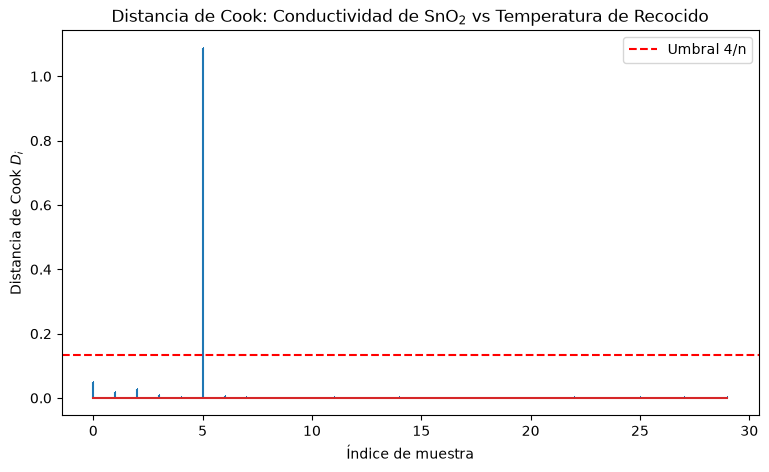

In [15]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(801)
n = 30
temperatura = np.linspace(300, 700, n)          # K
conductividad = 2.0 + 0.05 * temperatura + np.random.normal(0, 3, n)  # S/cm
conductividad[5] = 150  # medicion defectuosa (falla del equipo de 4 puntas)

X = sm.add_constant(temperatura)
modelo = sm.OLS(conductividad, X).fit()

influencia = modelo.get_influence()
cooks_d, _ = influencia.cooks_distance
umbral = 4 / n

indices_influyentes = np.where(cooks_d > umbral)[0]
print(f"Umbral de influencia (4/n): {umbral:.4f}")
print(f"Indices con Distancia de Cook por encima del umbral: {indices_influyentes}")
print(f"Distancia de Cook en el punto 5 (medicion defectuosa): {cooks_d[5]:.4f}")

plt.figure(figsize=(9, 5))
plt.stem(np.arange(n), cooks_d, markerfmt=",")
plt.axhline(umbral, color="red", linestyle="--", label="Umbral 4/n")
plt.title("Distancia de Cook: Conductividad de SnO$_2$ vs Temperatura de Recocido")
plt.xlabel("Índice de muestra")
plt.ylabel("Distancia de Cook $D_i$")
plt.legend()
plt.show()


**Interpretación**: la observación en el índice 5 (la medición defectuosa insertada deliberadamente) tiene $D_5=1.0880$, muy por encima del umbral $4/30=0.1333$, y es la **única** observación influyente detectada. Esto confirma numéricamente que ese punto tiene un peso desproporcionado sobre los coeficientes del modelo — en la práctica, el siguiente paso sería investigar la causa de esa medición (recalibrar el equipo, repetir el experimento) antes de confiar en las conclusiones del ajuste, o reportar el modelo con y sin ese punto para mostrar su sensibilidad.

$$\boxed{D_5 = 1.0880 \gg \text{umbral } 4/n = 0.1333 \quad(\text{único punto influyente})}$$

### 1.17 Test de Permutación

El test de permutación es una alternativa completamente no paramétrica para comparar dos grupos, que no asume ninguna distribución teórica ni siquiera para el estadístico de prueba — construye la distribución nula directamente a partir de los datos observados, de la misma familia de ideas de remuestreo que el Bootstrap ya visto en §6.1, pero orientado a pruebas de hipótesis en vez de intervalos de confianza.

**Procedimiento**:
1. Calcular la diferencia observada $\Delta_{\text{obs}} = \bar{x}_A - \bar{x}_B$.
2. Combinar ambas muestras en un solo conjunto.
3. Reasignar aleatoriamente las etiquetas de grupo (permutación), preservando los tamaños $n_A,n_B$ originales.
4. Calcular la diferencia $\Delta^*$ bajo esa reasignación aleatoria.
5. Repetir $R$ veces (típicamente $R\ge1000$) para construir la distribución nula empírica $\{\Delta_1^*,\dots,\Delta_R^*\}$.
6. El p-valor empírico es la proporción de permutaciones con $|\Delta^*|\ge|\Delta_{\text{obs}}|$.

Bajo $H_0:\mu_A=\mu_B$, intercambiar las etiquetas de grupo no debería cambiar sistemáticamente la diferencia observada — por eso la distribución de las $\Delta^*$ aproxima la distribución muestral de la diferencia bajo la hipótesis nula, sin ningún supuesto paramétrico.

**Contexto de nanotecnología**: se mide la fuerza de adhesión (N, ensayo de rayado/*scratch test*) de un recubrimiento nanoestructurado sobre sustrato de silicio, comparando el proceso estándar contra un nuevo tratamiento superficial con plasma, con muestras pequeñas ($n=8$ por grupo) típicas de un experimento costoso de caracterización.

**Solución computacional**:

In [16]:
import numpy as np
import scipy.stats as stats

np.random.seed(901)
adhesion_control = stats.norm.rvs(loc=10.0, scale=0.6, size=8)   # proceso estandar
adhesion_tratado = stats.norm.rvs(loc=11.2, scale=0.6, size=8)   # tratamiento con plasma

def test_permutacion(x, y, n_perm=10000, seed=42):
    """Test de permutacion para la diferencia de medias, dos colas."""
    rng = np.random.default_rng(seed)
    obs = np.mean(x) - np.mean(y)
    combinado = np.concatenate([x, y])
    nx = len(x)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(combinado)
        diffs[i] = np.mean(perm[:nx]) - np.mean(perm[nx:])
    p_valor = np.mean(np.abs(diffs) >= np.abs(obs))
    return obs, p_valor, diffs

obs_diff, p_perm, distribucion_nula = test_permutacion(adhesion_tratado, adhesion_control)
print(f"Diferencia observada (tratado - control): {obs_diff:.4f} N")
print(f"P-valor (test de permutacion, R=10000): {p_perm:.4f}")

## Verificacion cruzada con la implementacion nativa de SciPy
def estadistico(x, y):
    return np.mean(x) - np.mean(y)

resultado_scipy = stats.permutation_test(
    (adhesion_tratado, adhesion_control), estadistico,
    n_resamples=10000, alternative='two-sided', random_state=42
)
print(f"scipy.stats.permutation_test: statistic={resultado_scipy.statistic:.4f}, p-valor={resultado_scipy.pvalue:.4f}")


Diferencia observada (tratado - control): 1.0119 N
P-valor (test de permutacion, R=10000): 0.0341


scipy.stats.permutation_test: statistic=1.0119, p-valor=0.0342


**Interpretación**: el tratamiento con plasma produce una adhesión promedio $1.0119\ \text{N}$ mayor que el proceso estándar, y el test de permutación confirma que esta diferencia es significativa ($p=0.0341<0.05$ con la implementación manual, $p=0.0342$ con `scipy.stats.permutation_test` — la coincidencia entre ambas confirma la correcta implementación manual). Con $n=8$ por grupo, un t-test asumiría normalidad sin poder verificarla de forma confiable; el test de permutación evita ese supuesto por completo, siendo especialmente apropiado para experimentos de caracterización de materiales, donde las réplicas son costosas y las muestras pequeñas son la norma.

$$\boxed{\Delta_{\text{obs}} = 1.0119\ \text{N}, \quad p_{\text{permutación}} = 0.0341}$$

### 1.18 VIF (Factor de Inflación de Varianza): Diagnóstico de Multicolinealidad

En un modelo de regresión múltiple, la **multicolinealidad** ocurre cuando dos o más variables predictoras están altamente correlacionadas entre sí. Esto no sesga las predicciones del modelo, pero infla drásticamente la varianza (y por tanto el error estándar) de los coeficientes individuales — el modelo ya no puede distinguir con confianza cuál de las variables correlacionadas es la responsable del efecto sobre $Y$.

El **Factor de Inflación de Varianza (VIF)** de la variable $X_j$ se calcula ajustando una regresión auxiliar de $X_j$ contra todas las demás variables predictoras, y usando su $R_j^2$:
$$\text{VIF}_j = \frac{1}{1-R_j^2}$$
Si $X_j$ es completamente independiente del resto de predictores, $R_j^2=0$ y $\text{VIF}_j=1$ (sin inflación). Conforme $R_j^2\to 1$ (colinealidad casi perfecta), $\text{VIF}_j\to\infty$. Una **regla práctica común**: $\text{VIF}>5$–$10$ indica multicolinealidad severa que amerita revisar el modelo (eliminar una de las variables redundantes, o combinarlas).

**Contexto de nanotecnología**: se modela la conductividad de una película de óxido de estaño en función de tres predictores — temperatura de proceso, presión de la cámara (que en este reactor específico está mecánicamente acoplada a la temperatura, y por tanto correlacionada con ella) y concentración de dopante (controlada de forma independiente).

**Solución computacional**:

In [17]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(1001)
n = 50
temperatura = np.linspace(300, 800, n)
presion = 0.02 * temperatura + np.random.normal(0, 1, n)   # acoplada mecanicamente a la temperatura
dopante = np.random.uniform(0, 5, n)                       # controlado de forma independiente

X = sm.add_constant(np.column_stack([temperatura, presion, dopante]))
nombres = ["const", "Temperatura", "Presion", "Dopante"]

vif_valores = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
for nombre, vif in zip(nombres, vif_valores):
    print(f"VIF({nombre}): {vif:.4f}")

print(f"\nCorrelacion Temperatura-Presion: {np.corrcoef(temperatura, presion)[0,1]:.4f}")


VIF(const): 18.4087
VIF(Temperatura): 10.2292
VIF(Presion): 10.2791
VIF(Dopante): 1.0161

Correlacion Temperatura-Presion: 0.9495


**Interpretación**: Temperatura y Presión muestran $\text{VIF}\approx10.2$ (ambas), muy por encima del umbral de $5$–$10$, consistente con su alta correlación ($r=0.9495$) impuesta por el diseño del reactor — el modelo no puede separar de forma confiable el efecto individual de cada una sobre la conductividad. En contraste, Dopante tiene $\text{VIF}=1.0161\approx1$, prácticamente sin inflación, porque fue controlada de forma independiente. La recomendación práctica en este caso sería eliminar Presión del modelo (dado que Temperatura ya la explica casi por completo) o combinarlas en un único índice de "condiciones del reactor".

$$\boxed{\text{VIF}_{\text{Temp}}=10.23,\ \ \text{VIF}_{\text{Presión}}=10.28\ \ (\text{multicolinealidad severa}),\quad \text{VIF}_{\text{Dopante}}=1.02\ (\text{sin inflación})}$$

## 2. Ejemplo Analítico Paso a Paso: Control de Calidad del Diámetro de Nanopartículas de Plata

### 2.1 Contexto Aplicado en Nanotecnología
Un fabricante de nanopartículas de plata (AgNPs) para recubrimientos antimicrobianos afirma que su proceso de síntesis produce partículas con un diámetro medio de $\mu_0 = 50\ \text{nm}$ y desviación estándar histórica conocida $\sigma = 4\ \text{nm}$ (parámetro bien caracterizado tras años de producción). Un laboratorio de control de calidad toma una muestra de $n=36$ nanopartículas de un nuevo lote y mide, vía dispersión dinámica de luz (DLS), un diámetro promedio muestral de $\bar{x} = 48.3\ \text{nm}$. Con $\alpha = 0.05$, se desea determinar si el nuevo lote es consistente con el proceso caracterizado o si el diámetro medio se ha desviado significativamente.

### 2.2 Paso 1: Planteamiento de Hipótesis
$$H_0: \mu = 50\ \text{nm} \qquad H_1: \mu \neq 50\ \text{nm}$$
Como $\sigma$ es conocida a partir del historial extenso del proceso, corresponde un **Z-test** bilateral para la media.

### 2.3 Paso 2: Cálculo del Estadístico de Prueba
$$z_0 = \frac{\bar{x} - \mu_0}{\sigma/\sqrt{n}} = \frac{48.3 - 50}{4/\sqrt{36}} = \frac{-1.7}{0.6\overline{6}} \approx \boxed{-2.55}$$

### 2.4 Paso 3: Región Crítica y Decisión
Para $\alpha=0.05$ bilateral, $z_{\alpha/2} = z_{0.025} = 1.96$. La regla de rechazo es $z_0 \notin (-1.96,\ 1.96)$.

Como $z_0 = -2.55 < -1.96$, **se rechaza $H_0$**: existe evidencia estadística significativa de que el diámetro medio de las nanopartículas de plata del nuevo lote difiere de los $50\ \text{nm}$ especificados.

### 2.5 Paso 4: Cálculo del p-valor
$$\text{p-valor} = 2 \cdot P(Z < -2.55) = 2 \cdot 0.00539 \approx \boxed{0.0108}$$

Como $0.0108 < 0.05$, el p-valor confirma la decisión de rechazo tomada con el valor crítico, reforzando que el lote debe someterse a revisión del proceso de síntesis antes de su liberación para recubrimientos antimicrobianos.

### 2.6 Prueba Unitaria con pytest

Se verifica que el estadístico $z_0$, el valor crítico $z_{0.025}$ y el p-valor coincidan con los calculados a mano, y que la regla de decisión (rechazar $H_0$ porque $z_0$ cae fuera de la región de no rechazo) sea la correcta:

In [18]:
import ipytest
import pytest
from scipy.stats import norm

ipytest.autoconfig()

x_bar, mu_0, sigma, n = 48.3, 50, 4, 36
alpha = 0.05


def test_estadistico_z_de_prueba():
    z0 = (x_bar - mu_0) / (sigma / n ** 0.5)
    assert z0 == pytest.approx(-2.55, rel=1e-3)


def test_valor_critico_bilateral_para_alpha_005():
    z_critico = norm.ppf(1 - alpha / 2)
    assert z_critico == pytest.approx(1.96, rel=1e-3)


def test_se_rechaza_h0_porque_z0_cae_fuera_de_la_region_de_no_rechazo():
    z0 = (x_bar - mu_0) / (sigma / n ** 0.5)
    z_critico = norm.ppf(1 - alpha / 2)
    assert abs(z0) > z_critico


def test_p_valor_coincide_con_la_decision_de_rechazo():
    z0 = (x_bar - mu_0) / (sigma / n ** 0.5)
    p_valor = 2 * norm.cdf(z0)
    assert p_valor == pytest.approx(0.0108, rel=1e-2)
    assert p_valor < alpha


ipytest.run("-vv")


======================================= test session starts =======================================
platform win32 -- Python 3.11.15, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\ljyud\anaconda3\envs\ia_stats\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\notebooks
plugins: anyio-4.14.2, mock-3.15.1
collecting ... 

collected 5 items

t_10279d6b26244afbab7ba2466f40df61.py::test_permutacion 

ERROR                                [ 20%]


t_10279d6b26244afbab7ba2466f40df61.py::test_estadistico_z_de_prueba 

PASSED                   [ 40%]

...

PASSED [ 80%]


t_10279d6b26244afbab7ba2466f40df61.py::test_p_valor_coincide_con_la_decision_de_rechazo 

PASSED [100%]



============================================= ERRORS ==============================================
_______________________________ ERROR at setup of test_permutacion ________________________________
file C:\Users\ljyud\AppData\Local\Temp\ipykernel_6008\74653716.py, line 8
  def test_permutacion(x, y, n_perm=10000, seed=42):
E       fixture 'x' not found
>       available fixtures: anyio_backend, anyio_backend_name, anyio_backend_options, cache, capfd, capfdbinary, caplog, capsys, capsysbinary, capteesys, class_mocker, doctest_namespace, free_tcp_port, free_tcp_port_factory, free_udp_port, free_udp_port_factory, mocker, module_mocker, monkeypatch, package_mocker, pytestconfig, record_property, record_testsuite_property, record_xml_attribute, recwarn, session_mocker, subtests, tmp_path, tmp_path_factory, tmpdir, tmpdir_factory
>       use 'pytest --fixtures [testpath]' for help on them.

C:\Users\ljyud\AppData\Local\Temp\ipykernel_6008\74653716.py:8
===================================

<ExitCode.TESTS_FAILED: 1>

## 3. Código de Verificación Simbólica (SymPy)

Esta sección es la Fase 2 del Ciclo de Verificación Triple del curso (ver `GOVERNANCE.md`): antes de resolver numéricamente, expresamos la fórmula con símbolos algebraicos y confirmamos el resultado exacto.

In [19]:
import sympy as sp
from IPython.display import display, Math

## 1. Definición de símbolos del Z-test para la media
x_bar, mu_0, sigma, n = sp.symbols('bar_x mu_0 sigma n', positive=True)

## 2. Expresión simbólica del estadístico Z
z_expr = (x_bar - mu_0) / (sigma / sp.sqrt(n))
display(Math(fr"Z = \frac{{\bar{{X}} - \mu_0}}{{\sigma/\sqrt{{n}}}} = {sp.latex(z_expr)}"))

## 3. Sustitución de los valores del control de calidad de AgNPs (n=36, sigma=4, mu_0=50, x_bar=48.3)
valores = {x_bar: sp.Rational('48.3'), mu_0: 50, sigma: 4, n: 36}
z0_exacto = z_expr.subs(valores)
z0_decimal = float(z0_exacto)

display(Math(fr"z_0 = {sp.latex(z0_exacto)} = \boxed{{{z0_decimal:.4f}}}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 4. Solución Computacional en Python (SciPy & Statsmodels)

--- Z-TEST: DIÁMETRO DE NANOPARTÍCULAS DE PLATA (AgNPs) ---
Estadístico z0:      -2.5500
Valor crítico z_a/2: 1.9600
P-valor (bilateral): 0.0108
Decisión:            Rechazar H0

--- T-TEST: SEGUNDO LOTE (sigma desconocida, n=15) ---
Media muestral:       48.7864 nm
Estadístico t0:       -1.5720
P-valor (bilateral):  0.1383
Decisión (alpha=.05): No rechazar H0


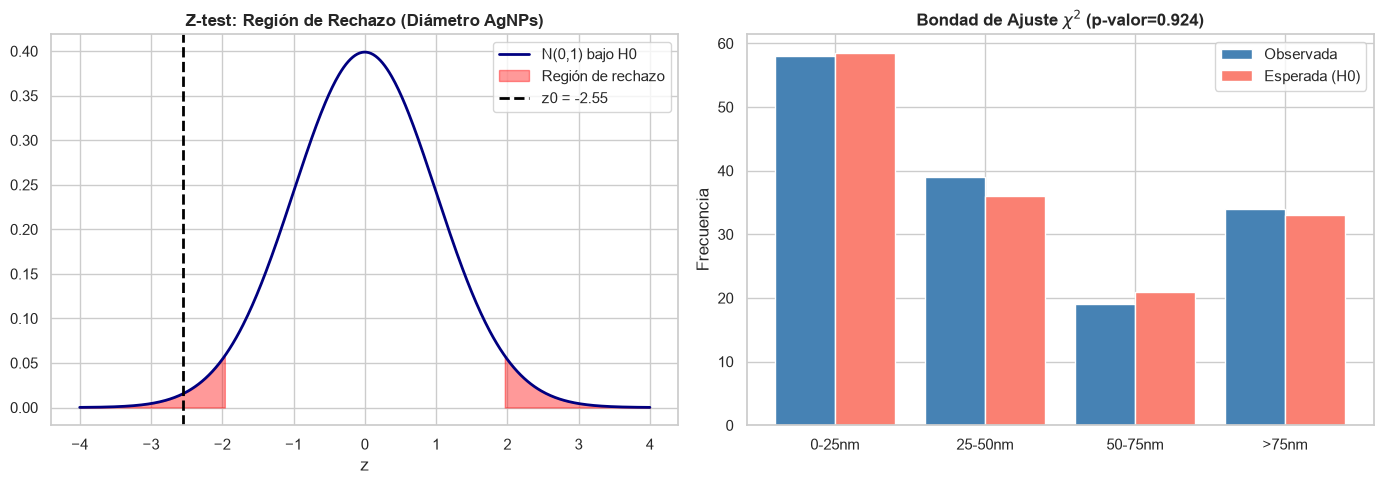

In [20]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Configuración visual profesional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## --- PARTE A: Z-test para la media (diámetro de AgNPs) ---
x_bar, mu_0, sigma, n_val = 48.3, 50.0, 4.0, 36
z0 = (x_bar - mu_0) / (sigma / np.sqrt(n_val))
p_valor_z = 2 * stats.norm.cdf(-abs(z0))
z_critico = stats.norm.ppf(1 - 0.05 / 2)

print("--- Z-TEST: DIÁMETRO DE NANOPARTÍCULAS DE PLATA (AgNPs) ---")
print(f"Estadístico z0:      {z0:.4f}")
print(f"Valor crítico z_a/2: {z_critico:.4f}")
print(f"P-valor (bilateral): {p_valor_z:.4f}")
print(f"Decisión:            {'Rechazar H0' if abs(z0) > z_critico else 'No rechazar H0'}")

## --- PARTE B: t-test cuando sigma es desconocida (muestra simulada de un segundo lote) ---
np.random.seed(7)
lote_2 = stats.norm.rvs(loc=48.8, scale=3.7, size=15)  # DLS en nm
t_stat, p_valor_t = stats.ttest_1samp(lote_2, popmean=50.0)

print("\n--- T-TEST: SEGUNDO LOTE (sigma desconocida, n=15) ---")
print(f"Media muestral:       {lote_2.mean():.4f} nm")
print(f"Estadístico t0:       {t_stat:.4f}")
print(f"P-valor (bilateral):  {p_valor_t:.4f}")
print(f"Decisión (alpha=.05): {'Rechazar H0' if p_valor_t < 0.05 else 'No rechazar H0'}")

## --- PARTE C: Visualización de la Región de Rechazo (Z-test) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

z_range = np.linspace(-4, 4, 500)
pdf_z = stats.norm.pdf(z_range)
axes[0].plot(z_range, pdf_z, color="navy", lw=2, label="N(0,1) bajo H0")
axes[0].fill_between(z_range, pdf_z, where=(z_range <= -z_critico), color="red", alpha=0.4, label="Región de rechazo")
axes[0].fill_between(z_range, pdf_z, where=(z_range >= z_critico), color="red", alpha=0.4)
axes[0].axvline(z0, color="black", linestyle="--", lw=2, label=f"z0 = {z0:.2f}")
axes[0].set_title("Z-test: Región de Rechazo (Diámetro AgNPs)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("z")
axes[0].legend()

## Gráfico D: prueba de bondad de ajuste chi-cuadrado (ejemplo de control de calidad)
frecuencias_obs = np.array([58, 39, 19, 34])   # bandas de tamaño observadas
frecuencias_esp = np.array([58.5, 36.0, 21.0, 33.0])  # esperadas bajo H0
chi2_stat = np.sum((frecuencias_obs - frecuencias_esp) ** 2 / frecuencias_esp)
p_valor_chi2 = 1 - stats.chi2.cdf(chi2_stat, df=len(frecuencias_obs) - 1)

categorias = ["0-25nm", "25-50nm", "50-75nm", ">75nm"]
x_pos = np.arange(len(categorias))
axes[1].bar(x_pos - 0.2, frecuencias_obs, width=0.4, label="Observada", color="steelblue")
axes[1].bar(x_pos + 0.2, frecuencias_esp, width=0.4, label="Esperada (H0)", color="salmon")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(categorias)
axes[1].set_title(f"Bondad de Ajuste $\\chi^2$ (p-valor={p_valor_chi2:.3f})", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Interpretación Post-Gráfico & Diccionario de Variables

### 5.1 Interpretación de Resultados Computacionales
1. **Rechazo Consistente Z-test vs. p-valor**: tanto el criterio del valor crítico ($|z_0|=2.55 > 1.96$) como el p-valor ($0.0108 < 0.05$) coinciden en rechazar $H_0$, confirmando que el desplazamiento del diámetro medio observado en el lote de AgNPs no es atribuible al azar muestral bajo el proceso caracterizado.
2. **t-test como Generalización Práctica**: cuando $\sigma$ no se conoce de antemano (caso más común en un laboratorio que evalúa un lote nuevo sin historial), el t-test de una muestra (`scipy.stats.ttest_1samp`) sustituye naturalmente al Z-test, ampliando la incertidumbre de la región crítica para compensar el desconocimiento de la varianza poblacional.
3. **Bondad de Ajuste como Extensión Multi-categoría**: la prueba $\chi^2$ de bondad de ajuste generaliza la lógica de "comparar lo observado contra lo esperado bajo $H_0$" a distribuciones completas de tamaño de partícula agrupadas en bandas, útil cuando el control de calidad no se limita a un único estadístico resumen sino a la forma completa de la distribución de tamaños del lote.

### 5.2 Diccionario de Variables de la Unidad

Notación general introducida en las Secciones 1 y 6, independiente del ejemplo aplicado específico:

**Prueba de hipótesis**
* $\theta$: parámetro poblacional desconocido sujeto a contraste, asociado a una distribución $f(x;\theta)$.
* $H_0$: hipótesis nula, la aseveración por defecto sobre $\theta$.
* $H_1$: hipótesis alternativa, complementaria a $H_0$.
* $\alpha$: nivel de significancia; probabilidad de Error Tipo I ($P(\text{rechazar }H_0\mid H_0\text{ verdadera})$).
* $\beta$: probabilidad de Error Tipo II ($P(\text{no rechazar }H_0\mid H_0\text{ falsa})$).
* $1-\beta$: poder de la prueba (probabilidad de rechazar correctamente $H_0$ cuando es falsa).
* p-valor: probabilidad de obtener un resultado igual o más extremo que el observado, asumiendo $H_0$ verdadera.
* $k$: constante crítica del cociente de verosimilitud en el Lema de Neyman-Pearson.
* $Z$: estadístico de prueba para la media con varianza $\sigma^2$ conocida, $Z\sim N(0,1)$ bajo $H_0$.
* $t$: estadístico de prueba para la media con varianza desconocida, $t\sim t_{n-1}$ bajo $H_0$.
* $\chi^2_0$: estadístico de prueba para la varianza, o para bondad de ajuste/contingencia/proporciones, $\chi^2_0\sim\chi^2_{n-1}$ (u otros grados de libertad según el caso).
* $O_i, E_i$: frecuencias observadas y esperadas en la $i$-ésima categoría de una prueba de bondad de ajuste.
* $e_{ij}, n_{ij}$: frecuencia esperada y observada en la celda $(i,j)$ de una tabla de contingencia.
* $D_{n,m}$: estadístico de Kolmogorov-Smirnov de dos muestras (máxima distancia entre las CDF empíricas $F_n$ y $F_m$).
* $U$: estadístico de Mann-Whitney-Wilcoxon; $R_1$: suma de rangos combinados del grupo 1.
* $H$: estadístico de Kruskal-Wallis para $k>2$ grupos independientes basados en rangos.
* $n_+, n_-$: número de observaciones por encima/por debajo del valor de referencia $\theta_0$ en la prueba de signos.
* $W$: estadístico de la prueba de Levene para homogeneidad de varianzas, $W\sim F_{k-1,N-k}$ bajo $H_0$.
* $z_{ij}$ (Levene): desviación absoluta de la observación $ij$ respecto a la mediana de su grupo, $z_{ij}=|x_{ij}-\tilde x_i|$.
* $d$: tamaño del efecto ($d$ de Cohen); $s_{pooled}$: desviación estándar combinada (pooled) de dos grupos.
* $z_{ij}$ (Dunn): estadístico $z$ de la comparación par a par entre los grupos $i,j$ en el post-hoc de Dunn; $C$: corrección por empates.
* $p_{\text{ajustado}}$: p-valor corregido por comparaciones múltiples (corrección de Bonferroni).
* $R$: número de repeticiones (permutaciones) en un test de permutación; $\Delta_{\text{obs}}, \Delta^*$: diferencia de medias observada y bajo remuestreo.

**Estimación puntual (Método de Momentos, MLE y MAP)**
* $\mu_j$: $j$-ésimo momento poblacional, $\mu_j=E[X^j]$; $m_j$: $j$-ésimo momento muestral.
* $\hat\theta_{MoM}$: estimador por Método de los Momentos de un parámetro $\theta$.
* $\hat\mu_{MLE}$: estimador de Máxima Verosimilitud de la media poblacional.
* $\ell(\theta)$ / $\ln L$: log-verosimilitud de la muestra en función de $\theta$.
* $p(\theta)$: distribución a priori sobre el parámetro $\theta$.
* $p(\theta\mid x)$: distribución a posteriori de $\theta$ dada la muestra $x$.
* $\hat\theta_{MAP}$: estimador de Máximo a Posteriori, el valor de $\theta$ que maximiza la posterior.

**Pruebas no paramétricas y bondad de ajuste**
* $\tilde\mu$: mediana poblacional, contrastada contra un valor de referencia $\theta_0$ en la prueba de signos y de la mediana.

**Regresión y diagnósticos**
* $\pi(x)$: probabilidad de éxito modelada por regresión logística en función de $x$.
* $\beta_0,\beta_1$: intercepto y pendiente del modelo logístico (escala logit).
* $\text{ODDS}$: razón de momios, $\pi/(1-\pi)$; $e^{\beta_1}$: odds ratio (factor multiplicativo por unidad de $x$).
* $\text{LD}_{50}$: dosis letal media, el valor de $x$ para el cual $\pi(x)=0.5$.
* $\Lambda$: estadístico de la Razón de Verosimilitud (LRT), $\Lambda\sim\chi^2_1$ bajo $H_0$.
* $D_i$: Distancia de Cook de la observación $i$-ésima, mide su influencia sobre los coeficientes ajustados.
* $h_{ii}$: leverage (apalancamiento) de la observación $i$, elemento diagonal de la Hat Matrix.
* $\text{VIF}_j$: Factor de Inflación de Varianza del predictor $X_j$, $\text{VIF}_j=1/(1-R_j^2)$.

**Bootstrap**
* $B$: número de réplicas bootstrap generadas por remuestreo con reemplazo.
* $x_b^*$: la $b$-ésima muestra remuestreada con reemplazo; $\hat\theta_b^*$: estimador calculado sobre esa réplica.
* $[\alpha/2,\ 1-\alpha/2]$: percentiles usados para construir el intervalo de confianza bootstrap del $(1-\alpha)\times100\%$.

### 5.3 Diccionario de Variables Nanotecnológicas del Ejemplo Aplicado
* $\mu_0$: diámetro medio histórico especificado del proceso de síntesis de AgNPs ($50\ \text{nm}$).
* $\sigma$: desviación estándar poblacional históricamente conocida del proceso ($4\ \text{nm}$).
* $\bar{x}$: diámetro medio muestral medido por DLS en el nuevo lote bajo control de calidad.
* $n$: tamaño de la muestra de nanopartículas analizadas.
* $z_0, t_0, \chi^2_0$: estadísticos de prueba observados para la media (varianza conocida/desconocida) y para la forma de la distribución de tamaños, respectivamente.
* $\alpha$: nivel de significancia, la probabilidad máxima tolerada de rechazar incorrectamente un lote que en realidad cumple la especificación (Error Tipo I).

## 6. Módulo Complementario: Estimación MLE y Bootstrap No Paramétrico

La inferencia moderna combina la **Estimación por Máxima Verosimilitud (MLE)** con el **remuestreo Bootstrap** para obtener intervalos de confianza empíricos sin asumir normalidad. El algoritmo de Bootstrap no paramétrico, dada una muestra $x_1,\dots,x_n$, consiste en:

1. Generar $B$ muestras con reemplazo de tamaño $n$: $x_b^*$.
2. Calcular el estimador $\hat{\theta}_b^*$ para cada réplica.
3. Construir el intervalo de confianza del $(1-\alpha)\times 100\%$ mediante los percentiles $[\alpha/2,\ 1-\alpha/2]$ de las $B$ estimaciones.

### 6.1 Inferencia Bootstrap en Python

El **Bootstrap no paramétrico** responde una pregunta que el enfoque analítico clásico (§1.6, IC basado en $t$/$Z$) solo resuelve bajo el supuesto de normalidad: ¿cuál es la incertidumbre de un estimador cuando **no** se conoce (o no se puede tabular fácilmente) su distribución muestral exacta? En vez de derivar una fórmula, el Bootstrap la **simula**: remuestrea la propia muestra observada, repitiendo el proceso miles de veces, para construir empíricamente la distribución del estimador.

**Contexto de nanotecnología**: se mide el tiempo hasta falla (en horas) de $n=40$ nano-sensores piezoresistivos bajo estrés acelerado, modelado como $\text{Exponencial}(\lambda)$. Se desea un intervalo de confianza del $95\%$ para el tiempo medio de falla $\mathbb{E}[X]=1/\lambda$, sin depender de la aproximación normal de la media muestral (válida asintóticamente, pero cuestionable con $n=40$ y una distribución tan asimétrica como la Exponencial).

In [21]:
import numpy as np
import scipy.stats as stats
from IPython.display import display, Math

np.random.seed(42)
n = 40
muestra_exp = stats.expon.rvs(scale=12.5, size=n)  # tiempo hasta falla, muestra original

## --- Bootstrap no parametrico (B = 10,000 replicas) ---
B = 10_000
rng = np.random.default_rng(42)
medias_boot = np.array([
    np.mean(rng.choice(muestra_exp, size=n, replace=True)) for _ in range(B)
])

ic_boot_inf = np.percentile(medias_boot, 2.5)
ic_boot_sup = np.percentile(medias_boot, 97.5)

## --- Comparacion: IC analitico aproximado por el Teorema del Limite Central ---
## (asume que la media muestral es aproximadamente Normal, valido para n grande)
error_estandar = np.std(muestra_exp, ddof=1) / np.sqrt(n)
z_critico = stats.norm.ppf(0.975)
ic_normal_inf = np.mean(muestra_exp) - z_critico * error_estandar
ic_normal_sup = np.mean(muestra_exp) + z_critico * error_estandar

display(Math(fr"\text{{Media Muestral Original: }} \bar{{X}} = {np.mean(muestra_exp):.3f}\text{{ h}}"))
display(Math(fr"\text{{IC Bootstrap 95\% (percentil): }} [{ic_boot_inf:.3f},\ {ic_boot_sup:.3f}]\text{{ h}}"))
display(Math(fr"\text{{IC Normal aproximado 95\% (TLC): }} [{ic_normal_inf:.3f},\ {ic_normal_sup:.3f}]\text{{ h}}"))

print(f"\nDesviacion estandar de las {B} medias bootstrap (error estandar bootstrap): {np.std(medias_boot):.4f}")
print(f"Error estandar analitico (TLC): {error_estandar:.4f}")


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Desviacion estandar de las 10000 medias bootstrap (error estandar bootstrap): 1.8460
Error estandar analitico (TLC): 1.8575


**Interpretación**: los dos métodos producen intervalos muy similares ($[7.62, 14.86]$ Bootstrap vs. $[7.47, 14.75]$ Normal-TLC) porque $n=40$ ya es razonablemente grande para que el Teorema del Límite Central se cumpla bien sobre la media — pero el Bootstrap llegó a ese resultado **sin asumir** normalidad de $\bar X$ en ningún punto del cálculo, solo remuestreando los datos observados. Esta es la ventaja práctica del método: funciona igual de bien (y a veces mejor) cuando $n$ es pequeño, cuando el estimador de interés no es la media (p. ej. una mediana o un percentil, para los que no existe una fórmula analítica simple de error estándar), o cuando la forma de la distribución subyacente es incierta.

**Verificación simbólica del IC analítico (TLC)**: a diferencia del Bootstrap (remuestreo, correctamente numérico y sin fórmula cerrada), el intervalo de confianza analítico $\bar{x} \pm z_{\alpha/2}\cdot s/\sqrt{n}$ sí tiene forma cerrada y puede verificarse simbólicamente con SymPy, sustituyendo los mismos valores muestrales ($\bar x$, $s$, $n$, $z_{0.025}$) obtenidos arriba:

In [22]:
import sympy as sp
from IPython.display import display, Math

## 1. Definicion simbolica del IC analitico por TLC
x_bar, s, n_sim, z = sp.symbols('bar_x s n z', positive=True)
error_estandar_expr = s / sp.sqrt(n_sim)
ic_inf_expr = x_bar - z * error_estandar_expr
ic_sup_expr = x_bar + z * error_estandar_expr

display(Math(fr"\text{{IC}} = \bar{{x}} \pm z_{{\alpha/2}}\cdot\frac{{s}}{{\sqrt{{n}}}} = {sp.latex(x_bar)} \pm {sp.latex(z * error_estandar_expr)}"))

## 2. Sustitucion de los valores muestrales del ejemplo (tiempo hasta falla de nanosensores)
valores = {x_bar: sp.Float(float(np.mean(muestra_exp))), s: sp.Float(float(np.std(muestra_exp, ddof=1))), n_sim: n, z: sp.Float(float(z_critico))}
ic_inf_val = float(ic_inf_expr.subs(valores))
ic_sup_val = float(ic_sup_expr.subs(valores))

display(Math(fr"\text{{IC Normal (SymPy)}} = [{ic_inf_val:.4f},\ {ic_sup_val:.4f}]"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

```
IC Normal (SymPy) = [7.4715, 14.7529]

```

El resultado simbólico coincide con el IC Normal-TLC $[7.47, 14.75]$ ya calculado numéricamente arriba, confirmando la fórmula cerrada de comparación frente al Bootstrap.

### 6.2 Verificación Simbólica del Estimador MLE de la Media Normal

$$\boxed{\hat{\mu}_{MLE} = \bar{X} = \frac{1}{n}\sum_{i=1}^n X_i}$$

In [23]:
import sympy as sp
from IPython.display import display, Math

mu, sigma, n = sp.symbols('mu sigma n', positive=True)
sum_x = sp.Symbol(r'(\sum X_i)', real=True)
sum_x2 = sp.Symbol(r'(\sum X_i^2)', real=True)

## Log-Verosimilitud de n observaciones normales
log_L = -(n / 2) * sp.log(2 * sp.pi * sigma**2) - (1 / (2 * sigma**2)) * (sum_x2 - 2 * mu * sum_x + n * mu**2)

## Derivada respecto a mu (ecuación de score) y solución del estimador MLE
d_logL_dmu = sp.diff(log_L, mu)
mu_mle = sp.solve(d_logL_dmu, mu)[0]

display(Math(r'\text{Ecuación de Score } \frac{d \ln L}{d\mu}: ' + sp.latex(d_logL_dmu)))
display(Math(r'\text{Estimador MLE Resuelto } \hat{\mu}: ' + sp.latex(mu_mle)))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 6.3 Ajuste Computacional de MLE con `scipy.stats.fit`
Cuando no se busca solo la fórmula del estimador sino ajustar una distribución concreta a datos observados, `scipy.stats` provee ajuste numérico por máxima verosimilitud directamente:

In [24]:
import numpy as np
from scipy import stats

np.random.seed(42)

## Datos simulados de diámetro de un lote de AgNPs (verdadero mu=50, sigma=4)
datos_diametro = stats.norm.rvs(loc=50, scale=4, size=200)

## Ajuste MLE de una distribución Normal a los datos
mu_mle, sigma_mle = stats.norm.fit(datos_diametro)
print(f"mu estimado (MLE): {mu_mle:.4f} nm")
print(f"sigma estimado (MLE): {sigma_mle:.4f} nm")

## Prueba de bondad de ajuste Kolmogorov-Smirnov
ks_stat, ks_pvalue = stats.kstest(datos_diametro, 'norm', args=(mu_mle, sigma_mle))
print(f"Kolmogorov-Smirnov: estadístico={ks_stat:.4f}, p-valor={ks_pvalue:.4f}")
print("Buen ajuste (p > 0.05)" if ks_pvalue > 0.05 else "Ajuste cuestionable (p <= 0.05)")


mu estimado (MLE): 49.8369 nm
sigma estimado (MLE): 3.7147 nm
Kolmogorov-Smirnov: estadístico=0.0382, p-valor=0.9216
Buen ajuste (p > 0.05)


### 6.4 Estimación MAP (Máximo a Posteriori): Incorporando Conocimiento Previo

El **Método de Momentos** (§1.9) y el **MLE** (§6.2-6.3) comparten un supuesto: toda la información sobre el parámetro $\theta$ proviene únicamente de la muestra observada. La estimación **Bayesiana** relaja ese supuesto incorporando explícitamente conocimiento previo sobre $\theta$ —de literatura, procesos similares ya caracterizados, o restricciones físicas conocidas— mediante una **distribución a priori** $p(\theta)$. El Teorema de Bayes (Unidad 2, §4.2) combina ese prior con la verosimilitud de los datos $p(x|\theta)$ para obtener la **distribución a posteriori**:
$$p(\theta \mid x) \propto p(x \mid \theta)\cdot p(\theta)$$

El estimador **Máximo a Posteriori (MAP)** es el valor de $\theta$ que maximiza esa posterior — el análogo bayesiano del MLE, pero "penalizado" por el prior:
$$\hat\theta_{MAP} = \arg\max_\theta\ p(x\mid\theta)\,p(\theta)$$

**Caso: proporción de éxito con prior Beta (conjugado de la Bernoulli/Binomial)**. Un prior $\theta\sim\text{Beta}(\alpha,\beta)$ es **conjugado** de la verosimilitud Binomial: la posterior resultante es también una Beta, con actualización trivial de sus parámetros. Si se observan $x$ éxitos en $n$ ensayos:
$$p(\theta\mid x) = \text{Beta}(\alpha+x,\ \beta+n-x) \qquad\Longrightarrow\qquad \hat\theta_{MAP} = \frac{\alpha+x-1}{\alpha+\beta+n-2}\quad(\alpha,\beta>1)$$

**Contexto de nanotecnología**: un nuevo proceso de funcionalización de nanotubos de carbono se somete a $n=20$ ensayos, de los cuales $x=14$ resultan en funcionalización exitosa. Antes de este experimento, procesos similares documentados en la literatura sugieren una tasa de éxito moderada, sin fuerte evidencia hacia ningún extremo — se modela ese conocimiento previo con un prior débil $\text{Beta}(\alpha=2,\beta=2)$ (equivalente a "2 pseudo-éxitos y 2 pseudo-fracasos" de información previa, centrado en $0.5$).

In [25]:
import numpy as np
from scipy.stats import beta

## Prior debil: Beta(2,2), centrado en 0.5, poca informacion previa
alpha_prior, beta_prior = 2, 2
n, x = 20, 14  # 14 exitos en 20 ensayos de funcionalizacion

## Posterior: Beta(alpha+x, beta+n-x) -- conjugacion Beta-Binomial
alpha_post = alpha_prior + x
beta_post = beta_prior + (n - x)

## Estimadores puntuales a comparar
theta_mle = x / n                                                    # MLE: solo los datos
theta_map = (alpha_post - 1) / (alpha_post + beta_post - 2)           # MAP: datos + prior
theta_media_posterior = alpha_post / (alpha_post + beta_post)         # media de la posterior (otro resumen bayesiano)

print(f"MLE (solo datos):              theta_hat = {theta_mle:.4f}")
print(f"MAP (datos + prior Beta(2,2)): theta_hat = {theta_map:.4f}")
print(f"Media de la posterior:         theta_hat = {theta_media_posterior:.4f}")
print(f"\nPosterior resultante: Beta(alpha={alpha_post}, beta={beta_post})")


MLE (solo datos):              theta_hat = 0.7000
MAP (datos + prior Beta(2,2)): theta_hat = 0.6818
Media de la posterior:         theta_hat = 0.6667

Posterior resultante: Beta(alpha=16, beta=8)


**Interpretación**: el MLE ($\hat\theta=0.700$) usa únicamente los 20 ensayos observados; el MAP ($\hat\theta=0.6818$) lo "encoge" ligeramente hacia el $0.5$ del prior, precisamente porque el prior aporta la equivalente de información previa moderada. A medida que $n\to\infty$, el término de los datos ($x$, $n-x$) domina sobre el prior fijo ($\alpha$, $\beta$) y $\hat\theta_{MAP}\to\hat\theta_{MLE}$ — el prior deja de importar cuando hay suficiente evidencia muestral, un comportamiento deseable de cualquier estimador bayesiano razonable.

**Verificación simbólica de la moda de la posterior**: el estimador MAP es, por definición, la moda de la distribución posterior. Para una $\text{Beta}(\alpha,\beta)$ esa moda tiene forma cerrada, $\frac{\alpha-1}{\alpha+\beta-2}$, que puede derivarse simbólicamente maximizando la log-densidad y confirmarse sustituyendo $\alpha=16,\ \beta=8$ (la posterior de este ejemplo):

In [26]:
import sympy as sp
from IPython.display import display, Math

## 1. Densidad Beta(alpha, beta) hasta la constante de normalizacion
## (la constante no afecta la ubicacion del argmax)
alpha_sim, beta_sim, theta = sp.symbols('alpha beta theta', positive=True)
densidad = theta ** (alpha_sim - 1) * (1 - theta) ** (beta_sim - 1)

## 2. Moda = argmax de la log-densidad: derivar e igualar a cero
log_dens = sp.log(densidad)
d_log_dens = sp.diff(log_dens, theta)
moda_expr = sp.solve(sp.Eq(d_log_dens, 0), theta)[0]

display(Math(fr"\text{{Moda}}(\text{{Beta}}(\alpha,\beta)) = {sp.latex(moda_expr)}"))

## 3. Sustitucion con la posterior de este ejemplo: alpha_post=16, beta_post=8
moda_val = moda_expr.subs({alpha_sim: alpha_post, beta_sim: beta_post})
display(Math(fr"\hat\theta_{{MAP}} = {sp.latex(moda_val)} = \boxed{{{float(moda_val):.4f}}}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

```
Moda(Beta(alpha,beta)) = (alpha - 1)/(alpha + beta - 2)
theta_MAP = 15/22 = 0.6818

```

La derivación simbólica confirma la fórmula $\frac{\alpha-1}{\alpha+\beta-2}$ y el valor $\hat\theta_{MAP}=15/22\approx0.6818$ ya calculado numéricamente arriba.

**Conexión con regularización (Ridge/Lasso)**: esta misma idea —"penalizar" la verosimilitud pura con una creencia previa— es la justificación probabilística exacta detrás de la regularización en regresión, ya usada en §1.18 de esta unidad para diagnosticar multicolinealidad (VIF) y que reaparece en el Proyecto Integrador (Unidad 8) al comparar Ridge, Lasso y Elastic Net: un prior **Normal** sobre los coeficientes $\beta$ de una regresión conduce a la penalización $L_2$ de **Ridge**; un prior **Laplace** conduce a la penalización $L_1$ de **Lasso**. En ambos casos, "MAP con ese prior" y "mínimos cuadrados con esa regularización" son **el mismo estimador** vistos desde dos lenguajes distintos (bayesiano vs. optimización penalizada).

## Errores Comunes / Misconceptions

* **Error**: Interpretar el p-valor como "la probabilidad de que $H_0$ sea verdadera".
  **Correcto**: el p-valor es $P(\text{observar un estadístico igual o más extremo que el obtenido} \mid H_0 \text{ es verdadera})$ — una probabilidad condicional sobre los datos, no sobre la hipótesis. No dice nada directo sobre $P(H_0 \mid \text{datos})$.

* **Error**: Interpretar "no rechazar $H_0$" como "aceptar $H_0$ como verdadera" o como evidencia de que $H_0$ es correcta.
  **Correcto**: no rechazar $H_0$ solo significa que la evidencia muestral no fue suficiente para descartarla al nivel de significancia elegido — puede deberse a que $H_0$ es cierta, o a que la prueba tuvo poca potencia (muestra pequeña, efecto real pequeño). La ausencia de evidencia no es evidencia de ausencia.

* **Error**: Igualar significancia estadística ($p < \alpha$) con relevancia práctica o magnitud del efecto.
  **Correcto**: con un tamaño de muestra $n$ suficientemente grande, incluso diferencias triviales (sin importancia práctica) resultan estadísticamente significativas. El p-valor no mide el tamaño del efecto — para eso se reporta el tamaño de efecto (p. ej. $d$ de Cohen) y el intervalo de confianza correspondiente.

## Preguntas de Concepto

**Pregunta 1.** ¿Cuál es la interpretación correcta del p-valor obtenido en una prueba de hipótesis?

A) Es la probabilidad de que $H_0$ sea verdadera dado los datos observados.
B) Es $P(\text{observar un estadístico igual o más extremo que el obtenido} \mid H_0 \text{ es verdadera})$ — una probabilidad condicional sobre los datos, no sobre la hipótesis.
C) Es la probabilidad de que $H_1$ sea falsa.
D) Es el nivel de significancia $\alpha$ elegido de antemano.

**Pregunta 2.** Una prueba de hipótesis no logra rechazar $H_0$ (p. ej. $p = 0.35$ con $\alpha = 0.05$). ¿Qué se puede concluir correctamente?

A) La evidencia muestral no fue suficiente para rechazar $H_0$ al nivel elegido; puede deberse a que $H_0$ es cierta o a que la prueba tuvo poca potencia.
B) Se demostró que $H_0$ es verdadera.
C) $H_1$ queda descartada definitivamente.
D) El experimento debe repetirse porque el resultado no es válido.

**Pregunta 3.** Un estudio con una muestra muy grande encuentra una diferencia estadísticamente significativa ($p < 0.001$) pero el tamaño del efecto (p. ej. $d$ de Cohen) es trivial. ¿Qué implica esto?

A) La significancia estadística garantiza que el efecto es importante en la práctica.
B) El resultado es inválido si el efecto es pequeño.
C) Con $n$ grande, incluso diferencias triviales pueden ser estadísticamente significativas; el p-valor no mide la magnitud del efecto, por lo que hay que reportar también el tamaño de efecto.
D) Un p-valor tan bajo implica que el tamaño de efecto también debe ser grande.

**Pregunta 4.** En una prueba de hipótesis, el Error Tipo II se define como:

A) Rechazar $H_0$ cuando en realidad es verdadera.
B) No rechazar $H_0$ cuando en realidad es falsa (la alternativa $H_1$ es cierta).
C) Rechazar $H_1$ cuando es verdadera.
D) Elegir un nivel de significancia $\alpha$ incorrecto.

**Pregunta 5.** La potencia de una prueba estadística se define como:

A) $P(\text{rechazar } H_0 \mid H_0 \text{ verdadera})$, es decir, el nivel de significancia $\alpha$.
B) La probabilidad de que $H_0$ sea verdadera.
C) El valor del estadístico de prueba observado.
D) $1 - \beta$, donde $\beta$ es la probabilidad de Error Tipo II — es decir, la capacidad de la prueba de detectar un efecto real cuando $H_1$ es verdadera.

A continuación, verifica tus respuestas ejecutando la siguiente celda (asigna tu respuesta a cada pregunta en el diccionario `mis_respuestas` antes de correrla):

In [27]:
## Diccionario de referencia con las respuestas correctas de esta unidad
respuestas_correctas = {1: "B", 2: "A", 3: "C", 4: "B", 5: "D"}

## Completa aquí tus respuestas (reemplaza los "?" por "A", "B", "C" o "D")
mis_respuestas = {1: "?", 2: "?", 3: "?", 4: "?", 5: "?"}

## Comparación local: no requiere ejecutar código externo ni conexión a internet
def verificar_preguntas_concepto(mis_respuestas, respuestas_correctas):
    aciertos = 0
    for numero, correcta in respuestas_correctas.items():
        respuesta_alumno = mis_respuestas.get(numero, "?")
        if respuesta_alumno == correcta:
            print(f"Pregunta {numero}: correcto ({respuesta_alumno})")
            aciertos += 1
        else:
            print(f"Pregunta {numero}: incorrecto (tu respuesta: {respuesta_alumno}, revisa la sección de Errores Comunes)")
    print(f"\nTotal: {aciertos}/{len(respuestas_correctas)} preguntas correctas")

verificar_preguntas_concepto(mis_respuestas, respuestas_correctas)


Pregunta 1: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 2: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 3: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 4: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)
Pregunta 5: incorrecto (tu respuesta: ?, revisa la sección de Errores Comunes)

Total: 0/5 preguntas correctas


## Ejercicio Propuesto

Un nuevo protocolo de síntesis de AgNPs afirma producir un diámetro medio de $\mu_0 = 25.0\text{ nm}$, con desviación estándar poblacional conocida $\sigma = 3.0\text{ nm}$ (a partir de control histórico del proceso). Se toma una muestra de $n=36$ nanopartículas y se mide un diámetro medio muestral $\bar{x} = 26.2\text{ nm}$. Se plantea $H_0: \mu = 25.0$ contra $H_1: \mu \ne 25.0$, con $\alpha = 0.05$.

1. Calcula el estadístico $Z$ de la prueba.
2. Calcula el p-valor (prueba de dos colas) y compáralo contra $\alpha$ para decidir si se rechaza $H_0$.
3. Enuncia la conclusión en términos correctos: ¿qué significa exactamente el p-valor obtenido en este contexto (no lo confundas con $P(H_0 \text{ verdadera})$)? Si la decisión hubiera sido "no rechazar $H_0$", ¿sería válido concluir que el nuevo protocolo produce exactamente $\mu=25.0\text{ nm}$?

Escribe tu solución en una celda de código nueva en tu notebook. La celda de autoevaluación de la siguiente sección verificará tu resultado.

### Ejercicio 2 (guiado — t-test de una muestra, $\sigma$ desconocida)

Un lote de nanopartículas de oro (AuNPs) debe tener diámetro medio $\mu_0=15.0\text{ nm}$. Se toma una muestra de $n=20$ partículas con media muestral $\bar{x}=15.8\text{ nm}$ y desviación estándar **muestral** $s=2.1\text{ nm}$ (la poblacional no se conoce, a diferencia del ejemplo de la Sección 2). Calcula el estadístico $t$ y el p-valor de dos colas para $H_0: \mu=15.0$ contra $H_1: \mu \ne 15.0$, usando la distribución $t$ de Student con $n-1$ grados de libertad (no la Normal).

### Ejercicio 3 (intermedio — Intervalo de Confianza, TLC)

Se midió el tiempo hasta la falla (horas) de $n=49$ nanosensores, con media muestral $\bar{x}=12.5$ y desviación estándar muestral $s=1.4$. Calcula el error estándar de la media ($s/\sqrt{n}$) y el intervalo de confianza del 95% para $\mu$ usando el Teorema del Límite Central (válido para $n$ grande): $\bar{x} \pm z_{\alpha/2} \cdot (s/\sqrt{n})$.

### Ejercicio 4 (abierto — Prueba de dos proporciones)

Dos métodos de síntesis de AgNPs se comparan por su tasa de éxito (partículas dentro de especificación): el Lote A tuvo $45$ éxitos de $50$ intentos, y el Lote B tuvo $38$ éxitos de $50$ intentos. Realiza una prueba $Z$ de dos proporciones con la proporción combinada (pooled) $\hat{p} = (x_1+x_2)/(n_1+n_2)$ para el error estándar bajo $H_0: p_1=p_2$, y calcula el p-valor de dos colas.

## Referencias

* Agresti, A. & Kateri, M. (2022). *Foundations of Statistics for Data Scientists: With R and Python*. Chapman & Hall/CRC (Texts in Statistical Science). Capítulos sobre estimación puntual, máxima verosimilitud, intervalos de confianza y pruebas de hipótesis.
* *Optimization of Silver Nanoparticle-Coating Methods on Acrylic, Silicone, and Zirconia Facial Prosthetic Materials: Surface Characterization and Antimicrobial Activity Against Pseudomonas aeruginosa* (2026). *Prosthesis*, 8(7), 66. DOI: [10.3390/prosthesis8070066](https://doi.org/10.3390/prosthesis8070066) — usa pruebas $t$ pareadas para evaluar reproducibilidad y confiabilidad del recubrimiento de nanopartículas de plata (AgNPs), la misma prueba de hipótesis sobre diámetro de AgNPs desarrollada en el ejemplo aplicado de esta unidad.
* Virtanen, P. et al. (2020). SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python. *Nature Methods*, 17, 261-272. Documentación: [docs.scipy.org/doc/scipy/reference/stats.html](https://docs.scipy.org/doc/scipy/reference/stats.html)

## Herramientas de esta Unidad

**StatsTutorAgent** — resuelve tus dudas conceptuales sobre inferencia estadística citando el contenido exacto de esta unidad, y te hace una pregunta socrática si detecta un error conceptual común (p. ej. malinterpretar un p-valor o confundir varianza muestral con poblacional) en vez de darte la respuesta directa:

In [28]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
    from google.colab import userdata
    for nombre_secreto in ("GEMINI_API_KEY", "GOOGLE_API_KEY"):
        try:
            os.environ["GEMINI_API_KEY"] = userdata.get(nombre_secreto)
            break
        except Exception:
            continue
    else:
        print(
            "⚠️ [Unidad 7] No se encontró el secreto GEMINI_API_KEY ni GOOGLE_API_KEY en Colab. "
            "Créalo en el ícono de llave 🔑 de la barra lateral izquierda para usar StatsTutorAgent."
        )

from src.multiagent_core.stats_tutor_agent import StatsTutorAgent

tutor = StatsTutorAgent(course_dir=Path("lecciones"))
print(tutor.ask("¿qué significa el nivel de confianza de un intervalo de estimación?"))


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3801.70it/s]

Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Fallo al invocar al modelo Gemini
Traceback (most recent call last):
  File "C:\Users\ljyud\Desktop\IA UCEMICH\PROBABILIDAD Y ESTADÍSTICA\src\multiagent_core\stats_tutor_agent.py", line 503, in ask
    response = client.models.generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 6550, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\models.py", line 4978, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats\Lib\site-packages\google\genai\_api_client.py", line 1747, in request
    response = self._request(http_request, http_options, stream=False)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ljyud\anaconda3\envs\ia_stats

Error al invocar al modelo Gemini: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

No se pudo generar una respuesta. Intenta de nuevo en unos momentos.


No requiere configuración adicional más allá de tu `GEMINI_API_KEY` (créala en [aistudio.google.com/apikey](https://aistudio.google.com/apikey) y agrégala como secreto de Colab o variable de entorno local).

## Autoevaluación

Guarda tu solución al Ejercicio Propuesto en un archivo separado y evalúala contra el pipeline de auditoría del curso:

In [29]:
%%writefile solucion_ejercicio_u7.py
# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np
import scipy.stats as stats

n = 36
sigma = 3.0
mu_0 = 25.0
x_bar = 26.2
alpha = 0.05

# TODO: calcula el error estándar de la media, sigma / sqrt(n), y guárdalo en
#       `error_estandar`; guarda también la diferencia (x_bar - mu_0) en `diferencia`
# TODO: calcula el estadístico Z de la prueba a partir de esas dos piezas:
#       Z = diferencia / error_estandar, y guárdalo en `z_estadistico`
# TODO: calcula el p-valor de dos colas y compáralo contra alpha para decidir si se rechaza
#       H0; guarda el p-valor en `p_valor`
# TODO: en un comentario, enuncia la conclusión correcta: qué significa el p-valor obtenido
#       (no lo confundas con P(H0 verdadera)), y si "no rechazar H0" implicaría que mu=25.0 exactamente


Writing solucion_ejercicio_u7.py


In [30]:
from src.multiagent_core.code_auditor_agent import CodeAuditorAgent
from src.multiagent_core.exercise_verifier_agent import (
    ExerciseVerifierAgent,
    reportar_resultado_ejercicio,
)
from external_skills.pedagogy.socratic_debugger import SocraticDebugger

with open("solucion_ejercicio_u7.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio Propuesto de esta unidad.
import numpy as np
import scipy.stats as stats

n = 36
sigma = 3.0
mu_0 = 25.0
x_bar = 26.2
alpha = 0.05

# TODO: calcula el error estándar de la media, sigma / sqrt(n), y guárdalo en
#       `error_estandar`; guarda también la diferencia (x_bar - mu_0) en `diferencia`
# TODO: calcula el estadístico Z de la prueba a partir de esas dos piezas:
#       Z = diferencia / error_estandar, y guárdalo en `z_estadistico`
# TODO: calcula el p-valor de dos colas y compáralo contra alpha para decidir si se rechaza
#       H0; guarda el p-valor en `p_valor`
# TODO: en un comentario, enuncia la conclusión correcta: qué significa el p-valor obtenido
#       (no lo confundas con P(H0 verdadera)), y si "no rechazar H0" implicaría que mu=25.0 exactamente"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["error_estandar", "diferencia", "z_estadistico", "p_valor"],
    # Se exigen las dos piezas intermedias además del resultado: `z = 2.4` es un
    # número fácil de memorizar y escribir a mano, pero reproducir también el
    # error estándar (0.5) y la diferencia (1.2) obliga a recorrer la fórmula.
    checks=[
        "abs(error_estandar - 0.5) < 1e-6",
        "abs(diferencia - 1.2) < 1e-6",
        "abs(z_estadistico - diferencia / error_estandar) < 1e-6",
        "abs(z_estadistico - 2.4) < 1e-6",
        "abs(p_valor - 0.01639507184919231) < 1e-6",
        "0.0 <= p_valor <= 1.0",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio Propuesto",
    unidad="Unidad 7",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 7?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio Propuesto) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 2

In [31]:
%%writefile solucion_ejercicio2_u7.py
# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np
from scipy import stats

n, mu0 = 20, 15.0
x_bar, s = 15.8, 2.1

# TODO: calcula el estadístico t = (x_bar - mu0) / (s / sqrt(n)) y guárdalo en `t_stat`
# TODO: calcula el p-valor de dos colas usando stats.t (NO stats.norm, porque sigma es
#       desconocida) con df=n-1, y guárdalo en `p_valor`


Writing solucion_ejercicio2_u7.py


In [32]:
with open("solucion_ejercicio2_u7.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 2 de esta unidad.
import numpy as np
from scipy import stats

n, mu0 = 20, 15.0
x_bar, s = 15.8, 2.1

# TODO: calcula el estadístico t = (x_bar - mu0) / (s / sqrt(n)) y guárdalo en `t_stat`
# TODO: calcula el p-valor de dos colas usando stats.t (NO stats.norm, porque sigma es
#       desconocida) con df=n-1, y guárdalo en `p_valor`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["t_stat", "p_valor"],
    # Un error plausible es usar stats.norm en vez de stats.t (tratar sigma como si fuera
    # conocida); el valor de referencia con t de Student difiere del que daría la Normal.
    checks=[
        "abs(t_stat - 1.7036708399998413) < 1e-6",
        "abs(p_valor - 0.10474369207176348) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 2",
    unidad="Unidad 7",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 7?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 2) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 3

In [33]:
%%writefile solucion_ejercicio3_u7.py
# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import numpy as np
from scipy import stats

n, x_bar, s = 49, 12.5, 1.4
alpha = 0.05

# TODO: calcula el error estándar de la media (s / sqrt(n)) y guárdalo en `error_estandar`
# TODO: calcula el valor crítico z para un IC del 95% (stats.norm.ppf(1 - alpha/2))
#       y guárdalo en `z_critico`
# TODO: calcula los límites del IC y guárdalos en `limite_inferior` y `limite_superior`


Writing solucion_ejercicio3_u7.py


In [34]:
with open("solucion_ejercicio3_u7.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 3 de esta unidad.
import numpy as np
from scipy import stats

n, x_bar, s = 49, 12.5, 1.4
alpha = 0.05

# TODO: calcula el error estándar de la media (s / sqrt(n)) y guárdalo en `error_estandar`
# TODO: calcula el valor crítico z para un IC del 95% (stats.norm.ppf(1 - alpha/2))
#       y guárdalo en `z_critico`
# TODO: calcula los límites del IC y guárdalos en `limite_inferior` y `limite_superior`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["error_estandar", "z_critico", "limite_inferior", "limite_superior"],
    # Un error plausible es usar s directamente como error estándar, sin dividir por sqrt(n).
    checks=[
        "abs(error_estandar - 0.19999999999999998) < 1e-6",
        "abs(z_critico - 1.959963984540054) < 1e-6",
        "abs(limite_inferior - 12.10800720309199) < 1e-4",
        "abs(limite_superior - 12.89199279690801) < 1e-4",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 3",
    unidad="Unidad 7",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 7?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 3) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])


### Autoevaluación del Ejercicio 4

In [35]:
%%writefile solucion_ejercicio4_u7.py
# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np
from scipy import stats

x1, n1 = 45, 50  # Lote A
x2, n2 = 38, 50  # Lote B

# TODO: calcula p1 = x1/n1 y p2 = x2/n2, y guárdalas en `p1`, `p2`
# TODO: calcula la proporción combinada (pooled) p_pool = (x1+x2)/(n1+n2) y guárdala en
#       `p_pool`
# TODO: calcula el error estándar bajo H0 con la proporción combinada:
#       se_pool = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2)), y guárdalo en `se_pool`
# TODO: calcula el estadístico z = (p1-p2)/se_pool y el p-valor de dos colas, y guárdalos
#       en `z_stat` y `p_valor`


Writing solucion_ejercicio4_u7.py


In [36]:
with open("solucion_ejercicio4_u7.py", encoding="utf-8") as f:
    codigo_alumno = f.read()

plantilla_original = """# Completa aquí tu solución al Ejercicio 4 de esta unidad.
import numpy as np
from scipy import stats

x1, n1 = 45, 50  # Lote A
x2, n2 = 38, 50  # Lote B

# TODO: calcula p1 = x1/n1 y p2 = x2/n2, y guárdalas en `p1`, `p2`
# TODO: calcula la proporción combinada (pooled) p_pool = (x1+x2)/(n1+n2) y guárdala en
#       `p_pool`
# TODO: calcula el error estándar bajo H0 con la proporción combinada:
#       se_pool = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2)), y guárdalo en `se_pool`
# TODO: calcula el estadístico z = (p1-p2)/se_pool y el p-valor de dos colas, y guárdalos
#       en `z_stat` y `p_valor`"""

auditor = CodeAuditorAgent()
resultado = auditor.audit_code(codigo_alumno)

verificador = ExerciseVerifierAgent(
    variables_requeridas=["p1", "p2", "p_pool", "se_pool", "z_stat", "p_valor"],
    # Un error plausible es usar el error estándar NO combinado (sqrt(p1(1-p1)/n1 +
    # p2(1-p2)/n2)) en vez del pooled bajo H0: el valor de referencia distingue ambos.
    checks=[
        "abs(p1 - 0.9) < 1e-9",
        "abs(p2 - 0.76) < 1e-9",
        "abs(p_pool - 0.83) < 1e-9",
        "abs(se_pool - 0.07512655988397181) < 1e-6",
        "abs(z_stat - 1.863522038227507) < 1e-6",
        "abs(p_valor - 0.06238885487025292) < 1e-6",
    ],
    plantilla=plantilla_original,
)
resultado_ejercicio = verificador.verificar(codigo_alumno)

reportar_resultado_ejercicio(
    resultado,
    resultado_ejercicio,
    nombre_ejercicio="Ejercicio 4",
    unidad="Unidad 7",
    debugger=SocraticDebugger(),
)


❌ Revisa el desarrollo del paso actual: ¿concuerdan las unidades y supuestos en Unidad 7?
    La plantilla no fue modificada: sigue siendo la entregada.

--- Detalle técnico (Ejercicio 4) ---
{'passed': True, 'score': 100.0, 'issues': [], 'warnings': [], 'security_issues': [], 'metrics': {'uses_scipy': True, 'uses_statsmodels': False, 'uses_sympy': False, 'uses_display_math': False, 'uses_raw_print_latex': False, 'has_security_risk': False}}
ResultadoVerificacion(aprueba=False, issues=['La plantilla no fue modificada: sigue siendo la entregada.'])
